# This is Group 40's Jupyter Notebook for EC1B1 Coursework (2026)

This is the notebook of group 40. The target country is Spain. Group members are Yiming Li, Mingyun Wang, and Hongyu Ye.

The group's conclusion regarding 'Whether exchange rates matter' is that notable exchange rate fluctuations in the history have often come with many confounding events, so it is hard to isolate the impact of exchange rates and judge its importance. In certain cases (e.g., Spain's case following the Bretton Wood's collapse), changes in exchange rate systems might be potentially associated with changes in economic performances, whereas in some cases (e.g., the UK's joining and leaving ERM), exchange rates seemed rather unimportant.

# 3, Data Cleaning

## 3.1, 'Downloading' (Collecting) Data

I uploaded the coursework data csv files to my github, so make sure you read these files **with internet connection** while running this notebook.

Imported are the monthly data from Dec 1959 to Dec 1990 of:
1. the CPI of the US
2. the total international reserves
3. Spain's CPI
4. The nominal exchange rate of the Spanish peseto per USD
5. Spain's industrial production index
6. Spain's total international reserves

In [ ]:
US_CPI = pd.read_csv('https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/US_CPI_monthly_index.csv')
US_total_reserves = pd.read_csv('https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/US_total_reserves_monthly_million_dollars.csv')
spain_CPI = pd.read_csv('https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/spain_CPI_monthly_index.csv')
spain_exchange_rate = pd.read_csv('https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/spain_exchange_rate_monthly_average.csv')
spain_industrial_production = pd.read_csv('https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/spain_industrial_production_monthly_index.csv')
spain_total_reserves = pd.read_csv('https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/spain_total_reserves_monthly_million_dollars.csv')

inspect

In [ ]:
files = [US_CPI, US_total_reserves, spain_CPI, spain_exchange_rate, spain_industrial_production, spain_total_reserves]
for file in files:
  display(file.head(1))

,COUNTRY,INDEX_TYPE,TIME_PERIOD,OBS_VALUE
0,United States,Consumer price index (CPI),1959-M12,13.482806


,COUNTRY,INDICATOR,UNIT,TIME_PERIOD,OBS_VALUE,SCALE
0,United States,Total reserves (gold at national valuation),US dollar,1959-M12,21504.5,Millions


,COUNTRY,INDEX_TYPE,TIME_PERIOD,OBS_VALUE
0,Spain,Consumer price index (CPI),1959-M12,2.525752


,COUNTRY,INDICATOR,TIME_PERIOD,OBS_VALUE
0,Spain,Domestic currency per US Dollar,1959-M12,60.0


,COUNTRY,PRODUCTION_INDEX,TIME_PERIOD,OBS_VALUE
0,Spain,Industrial Production,1961-M01,18.68751


,COUNTRY,INDICATOR,UNIT,TIME_PERIOD,OBS_VALUE,SCALE
0,Spain,Total reserves (gold at national valuation),US dollar,1959-M12,200.0,Millions


## 3.2, Cleaning Data

### 3.2.1, Tidying up the Dataframes

Tidy up the dataframes:
1. rename 'COUNTRY' and 'TIME_PERIOD' as 'country' and 'time' respectively
2. rename the data columns as the names of the variables recorded
3. drop useless columns

In [ ]:
US_CPI = US_CPI.rename(columns={'OBS_VALUE': 'CPI'}).drop(columns=['INDEX_TYPE']).rename(columns={'COUNTRY': 'country', 'TIME_PERIOD': 'time'})
US_total_reserves = US_total_reserves.rename(columns={'OBS_VALUE': 'total_reserves_$mn'}).drop(columns=['INDICATOR', 'UNIT', 'SCALE']).rename(columns={'COUNTRY': 'country', 'TIME_PERIOD': 'time'})
spain_CPI = spain_CPI.rename(columns={'OBS_VALUE': 'CPI'}).drop(columns=['INDEX_TYPE']).rename(columns={'COUNTRY': 'country', 'TIME_PERIOD': 'time'})
spain_exchange_rate = spain_exchange_rate.rename(columns={'OBS_VALUE': 'ER_per$'}).drop(columns=['INDICATOR']).rename(columns={'COUNTRY': 'country', 'TIME_PERIOD': 'time'})
spain_industrial_production = spain_industrial_production.rename(columns={'OBS_VALUE': 'industrial_production_index'}).drop(columns=['PRODUCTION_INDEX']).rename(columns={'COUNTRY': 'country', 'TIME_PERIOD': 'time'})
spain_total_reserves = spain_total_reserves.rename(columns={'OBS_VALUE': 'total_reserves_$mn'}).drop(columns=['INDICATOR', 'UNIT', 'SCALE']).rename(columns={'COUNTRY': 'country', 'TIME_PERIOD': 'time'})

merge the dataframes of the same country to create the tidied-up dataframes for the United States and Spain

In [ ]:
US = pd.merge(US_CPI, US_total_reserves, on=['country', 'time'], how='outer')
spain = pd.merge(spain_CPI, spain_exchange_rate, on=['country', 'time'], how='outer').merge(spain_industrial_production, on=['country', 'time'], how='outer').merge(spain_total_reserves, on=['country', 'time'], how='outer')

In [ ]:
display(US.tail(3))
display(spain.head(3))

,country,time,CPI,total_reserves_$mn
370,United States,1990-M10,61.222946,82852.196532
371,United States,1990-M11,61.360525,83059.402774
372,United States,1990-M12,61.360525,83316.214608


,country,time,CPI,ER_per$,industrial_production_index,total_reserves_$mn
0,Spain,1959-M12,2.525752,60.0,NaN,200.0
1,Spain,1960-M01,2.505928,60.0,NaN,233.0
2,Spain,1960-M02,2.503895,60.0,NaN,253.0


### 3.2.2, Creating Variables

#### Spain

1. monthly growth in the nominal exchange rate: ***gr(nER)ₙ = 100% \* (nERₙ - nERₘ) / nERₘ***

(where 'n' means this period and 'm' means the previous period)

Since the exchange rate is in **spanish peseta per USD**, a **positive growth** rate in this nominal exchange rate would mean a **depreciation** of the spanish peseta (vice versa) against the USD.

In [ ]:
# which means, in code:
gr_nER = ['NaN']
for i in range(1, len(spain)):
  gr_nER_i = 100 * (spain['ER_per$'][i] - spain['ER_per$'][i-1]) / spain['ER_per$'][i-1]
  gr_nER.append(gr_nER_i)
spain['gr_nER_%'] = gr_nER

# or simply spain spain['gr_nER_%'] = spain['ER_per$].pct_change() * 100

2. monthly growth in the real exchange rate

For period n, define real exchange rate (spanish peseta against USD):

***rERₙ = nERₙ \* CPIᵤ / CPIₛ***.

This adapts the exchange rate between the peseta and the USD to the relative purchasing power in the two countries. Meaning: how many spanish good bundles is one US good bundle worth. Then, the **rising of this real exchange rate** indicates weaker purchasing power of the peseta compared to the USD, AKA a **depreciation of the spanish peseta against the USD in terms of Real Purchasing Power**.

Then calculate the growth rates of this real exchange rate: ***gr(rER)ₙ = 100% \* (rERₙ - rERₘ) / rERₘ***

In [ ]:
rER = []
for i in range(len(spain)):
  rER_i = spain['ER_per$'][i] * US['CPI'][i] / spain['CPI'][i]
  rER.append(rER_i)
gr_rER = ['NaN']
for i in range(1, len(spain)):
  gr_rER_i = 100 * (rER[i] - rER[i-1]) / rER[i-1]
  gr_rER.append(gr_rER_i)
spain['gr_rER_%'] = gr_rER

3. real exchange rate index, with index for 1990 real ER equal to 1

define real exchange rate index rₜ:

***rₜ = rERₜ / rER(Dec, 1990)***

rₜ is therefore defined on the set of positive real rational numbers. Similarly, a greater rₜ value indicates a higher real exchange rate (peseta against USD) value in year t relative to in year 1990, and this also naturally mean the spanish peseta had weaker purchasing power in year t than in year 1990.

In [ ]:
r_t = []
for rer in rER:
  r_t_i = rer / rER[-1]
  r_t.append(r_t_i)
spain['rER_index'] = r_t

4. monthly inflation rate

AKA the growth rate in CPI.

***inflation_rateₙ = 100% \*(CPIₙ -  CPIₘ) / CPIₘ***

In [ ]:
spain['inflation_rate_%'] = spain['CPI'].pct_change() * 100

5. growth rate for industrial production

In [ ]:
spain['gr_ind_prod_%'] = spain['industrial_production_index'].pct_change() * 100

6. year_on year growth rate in industrial production

In [ ]:
spain['yr_on_yr_gr_ind_prod'] = spain['industrial_production_index'].pct_change(periods=12) * 100

7. index of the value of international reserves (value of reserves for January 1960 = 100)

In [ ]:
inter_res = []
for res in spain['total_reserves_$mn']:
  inter_res_i = 100 * res / spain['total_reserves_$mn'][1]
  inter_res.append(inter_res_i)
spain['reserves_index'] = inter_res
spain.head(3)

,country,time,CPI,ER_per$,industrial_production_index,total_reserves_$mn,gr_nER_%,gr_rER_%,rER_index,inflation_rate_%,gr_ind_prod_%,yr_on_yr_gr_ind_prod,reserves_index
0,Spain,1959-M12,2.525752,60.0,NaN,200.0,NaN,NaN,2.561868,NaN,NaN,NaN,85.836910
1,Spain,1960-M01,2.505928,60.0,NaN,233.0,0.0,0.448257,2.573352,-0.784875,NaN,NaN,100.000000
2,Spain,1960-M02,2.503895,60.0,NaN,253.0,0.0,0.422768,2.584231,-0.081128,NaN,NaN,108.583691


#### United States

1. monthly inflation rate

In [ ]:
US['inflation_rate_%'] = US['CPI'].pct_change() * 100

2. index of the value of international reserves (value of reserves for January 1960 = 100)

In [ ]:
inter_res = []
for res in US['total_reserves_$mn']:
  inter_res_i = 100 * res / US['total_reserves_$mn'][1]
  inter_res.append(inter_res_i)
US['reserves_index'] = inter_res

In [ ]:
display(US.head(3))
display(spain.head(3))

,country,time,CPI,total_reserves_$mn,inflation_rate_%,reserves_index
0,United States,1959-M12,13.482806,21504.5,NaN,100.122916
1,United States,1960-M01,13.436946,21478.1,-0.340136,100.000000
2,United States,1960-M02,13.482806,21395.7,0.341297,99.616353


,country,time,CPI,ER_per$,industrial_production_index,total_reserves_$mn,gr_nER_%,gr_rER_%,rER_index,inflation_rate_%,gr_ind_prod_%,yr_on_yr_gr_ind_prod,reserves_index
0,Spain,1959-M12,2.525752,60.0,NaN,200.0,NaN,NaN,2.561868,NaN,NaN,NaN,85.836910
1,Spain,1960-M01,2.505928,60.0,NaN,233.0,0.0,0.448257,2.573352,-0.784875,NaN,NaN,100.000000
2,Spain,1960-M02,2.503895,60.0,NaN,253.0,0.0,0.422768,2.584231,-0.081128,NaN,NaN,108.583691


## 3.3, End Product/Clean Data

In [ ]:
US['time'] = pd.to_datetime(US['time'], format='%Y-M%m').dt.to_period('M')
spain['time'] = pd.to_datetime(spain['time'], format='%Y-M%m').dt.to_period('M')

Let the two countries' data come together.

In [ ]:
all = pd.concat([spain, US])

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(all)

pd.reset_option('display.max_rows') # Reset options to default after displaying
pd.reset_option('display.max_columns') # Reset options to default after displaying

,country,time,CPI,ER_per$,industrial_production_index,total_reserves_$mn,gr_nER_%,gr_rER_%,rER_index,inflation_rate_%,gr_ind_prod_%,yr_on_yr_gr_ind_prod,reserves_index
0,Spain,1959-12,2.525752,60.000000,NaN,200.000000,NaN,NaN,2.561868,NaN,NaN,NaN,85.836910
1,Spain,1960-01,2.505928,60.000000,NaN,233.000000,0.0,0.448257,2.573352,-0.784875,NaN,NaN,100.000000
2,Spain,1960-02,2.503895,60.000000,NaN,253.000000,0.0,0.422768,2.584231,-0.081128,NaN,NaN,108.583691
3,Spain,1960-03,2.500846,60.000000,NaN,299.000000,0.0,0.121919,2.587382,-0.121770,NaN,NaN,128.326180
4,Spain,1960-04,2.502879,60.000000,NaN,326.000000,0.0,0.258633,2.594074,0.081292,NaN,NaN,139.914163
5,Spain,1960-05,2.495255,60.000000,NaN,360.000000,0.0,0.30554,2.602000,-0.304609,NaN,NaN,154.506438
6,Spain,1960-06,2.493221,60.000000,NaN,406.000000,0.0,0.420841,2.612950,-0.081515,NaN,NaN,174.248927
7,Spain,1960-07,2.492204,60.000000,NaN,427.000000,0.0,0.040807,2.614016,-0.040791,NaN,NaN,183.261803
8,Spain,1960-08,2.497288,60.000000,NaN,455.000000,0.0,-0.203581,2.608695,0.203996,NaN,NaN,195.278970
9,Spain,1960-09,2.512536,60.000000,NaN,479.000000,0.0,-0.606877,2.592863,0.610582,NaN,NaN,205.579399


# 4, Analyses

## 4.1, Exchange Rate and International Reserve Graphs

### 4.1.1, exchange rate variations

This section generates a comprehensive visual overview of Spain's exchange rate dynamics.

The 2x2 grid includes:

Nominal Growth: Monthly percentage changes in Pesetas/USD. (left, up)

Nominal Level: The raw exchange rate value. (right, up)

Real Growth: Monthly percentage changes in the Real Exchange Rate (adjusted for inflation). (left, down)

Real Index: The chained RER index (normalized to Dec 1990). (right, down)

Historical Context: A vertical dashed line is added at March 1973, representing the point when Spain moved away from the Bretton Woods fixed exchange rate system and allowed the peseta to float.

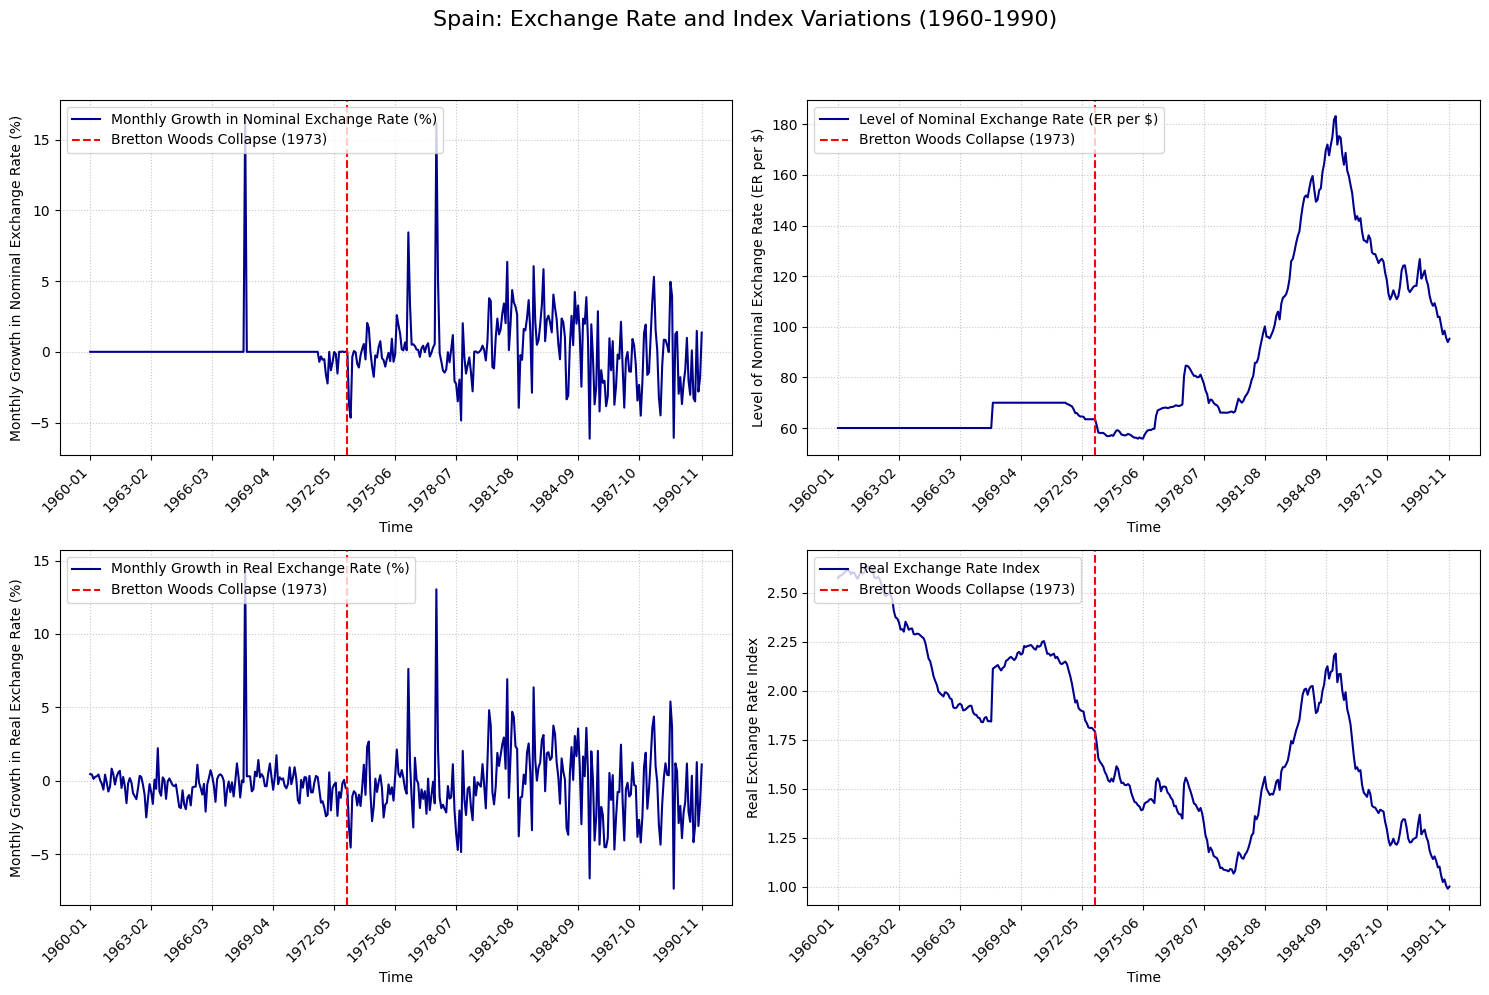

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filter the DataFrame for the specified period
filtered_spain = spain[(spain['time'] >= pd.Period('1960-01', 'M')) & (spain['time'] <= pd.Period('1990-12', 'M'))].copy()

# Convert object columns to numeric, coercing errors to NaN
for col in ['gr_nER_%', 'gr_rER_%']:
    filtered_spain[col] = pd.to_numeric(filtered_spain[col], errors='coerce')

# Define the variables to plot
plot_vars = {
    'gr_nER_%': 'Monthly Growth in Nominal Exchange Rate (%)',
    'ER_per$': 'Level of Nominal Exchange Rate (ER per $)',
    'gr_rER_%': 'Monthly Growth in Real Exchange Rate (%)',
    'rER_index': 'Real Exchange Rate Index'
}

# Create a figure and a set of subplots in a 2x2 matrix
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True)
fig.suptitle('Spain: Exchange Rate and Index Variations (1960-1990)', fontsize=16, y=1.02) # Adjust suptitle position

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Define the year 1973 for the vertical line
year_1973_period = pd.Period('1973-01', 'M') # Using January 1973 as the marker

# Plot each variable
for i, (col, title) in enumerate(plot_vars.items()):
    ax = axes[i]
    ax.plot(filtered_spain['time'].astype(str), filtered_spain[col], color='darkblue', label=title)
    ax.set_ylabel(title)
    ax.axvline(x=year_1973_period.strftime('%Y-%m'), color='red', linestyle='--', linewidth=1.5, label='Bretton Woods Collapse (1973)')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper left')
    ax.set_xlabel('Time') # Add x-axis label to all subplots

# Improve x-axis tick readability for PeriodIndex
n_ticks = 10 # Number of ticks to display
tick_labels = filtered_spain['time'].iloc[::len(filtered_spain['time']) // n_ticks].astype(str)
tick_positions = np.linspace(0, len(filtered_spain) - 1, len(tick_labels), dtype=int)

for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    ax.tick_params(labelbottom=True) # Ensure labels are shown on all subplots

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

### 4.1.2, international reserves 1960-1971, before the US exitted the Bretton Woods

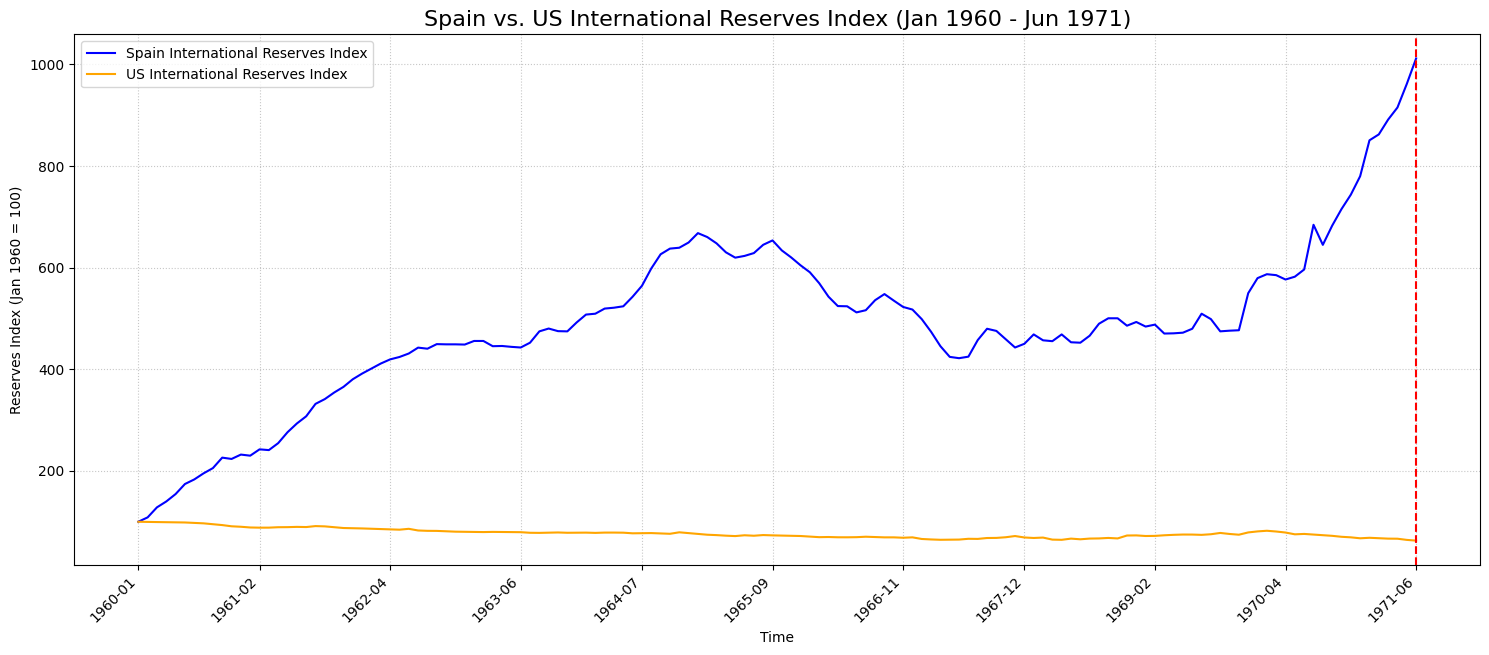

In [ ]:
# Define the period for filtering
start_period = pd.Period('1960-01', 'M')
end_period = pd.Period('1971-06', 'M')

# Filter the DataFrames for the specified period
filtered_spain_reserves = spain[(spain['time'] >= start_period) & (spain['time'] <= end_period)].copy()
filtered_us_reserves = US[(US['time'] >= start_period) & (US['time'] <= end_period)].copy()

# Ensure reserves_index is numeric
filtered_spain_reserves['reserves_index'] = pd.to_numeric(filtered_spain_reserves['reserves_index'], errors='coerce')
filtered_us_reserves['reserves_index'] = pd.to_numeric(filtered_us_reserves['reserves_index'], errors='coerce')

# Create the plot
plt.figure(figsize=(15, 7))

plt.plot(filtered_spain_reserves['time'].astype(str), filtered_spain_reserves['reserves_index'], label='Spain International Reserves Index', color='blue')
plt.plot(filtered_us_reserves['time'].astype(str), filtered_us_reserves['reserves_index'], label='US International Reserves Index', color='orange')

plt.title('Spain vs. US International Reserves Index (Jan 1960 - Jun 1971)', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Reserves Index (Jan 1960 = 100)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left')

# Define the year 1971-06 for the vertical line (US exit from Bretton Woods)
year_1971_period = pd.Period('1971-06', 'M')
# Find the numerical position for the vertical line
bw_exit_date_str = year_1971_period.strftime('%Y-%m')
x_vline_position = filtered_spain_reserves['time'].astype(str).tolist().index(bw_exit_date_str)

plt.axvline(x=x_vline_position, color='red', linestyle='--', linewidth=1.5, label='US Exits Bretton Woods (Jun 1971)')

# Improve x-axis tick readability for PeriodIndex
n_ticks = 10 # Number of ticks to display
tick_labels_auto = filtered_spain_reserves['time'].iloc[::len(filtered_spain_reserves['time']) // n_ticks].astype(str)
tick_positions_auto = np.linspace(0, len(filtered_spain_reserves) - 1, len(tick_labels_auto), dtype=int)

# Combine the automatic ticks with the BW exit tick to ensure it's always labeled
all_tick_positions = sorted(list(set(tick_positions_auto).union({x_vline_position})))
all_tick_labels = [filtered_spain_reserves['time'].astype(str).iloc[i] for i in all_tick_positions]

plt.xticks(all_tick_positions, all_tick_labels, rotation=45, ha='right')
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

### 4.1.3, Answers to the Questions
Q1: Was the US dollar over- or undervalued in the Bretton Woods system?

The US dollar was overvalued under the Bretton Woods system. The real exchange rate index shows that the peseta was significantly undervalued relative to the dollar during the Bretton Woods period (pre-1973), as the index stood well above 1 (around 2.5 in 1960, declining but still above 1.5 by 1973). This means it took more pesetas to buy a dollar than was justified by purchasing power, implying the dollar was overvalued relative to its true worth.

Q2: Using your graphs, explain one reason for the US's departure from Bretton Woods.

The international reserves graph shows that US reserves steadily declined from 1960 to 1971, falling to around 60% of their January 1960 level, while Spain's reserves grew dramatically (over 1000% by 1971). This reflects the so-called "Triffin Dilemma" — as the world's reserve currency, the US had to run persistent balance of payments deficits to supply dollars to the global economy, which continuously drained its gold reserves. By 1971, the US could no longer credibly maintain the dollar's convertibility to gold at $35 per ounce, forcing Nixon to abandon the peg.

## 4.2, Inflation and Industrial Production

###4.2.1, Inflation Comparison (Spain vs. US)
This section visualizes Spain's monthly inflation rate and the difference between Spain's and the US's inflation rates over time.

The 1x2 grid includes:

Spain's Monthly Inflation: Monthly percentage change in the Spanish CPI.
Inflation Differential: The difference between Spain's monthly inflation and the US's monthly inflation (Spain - US).

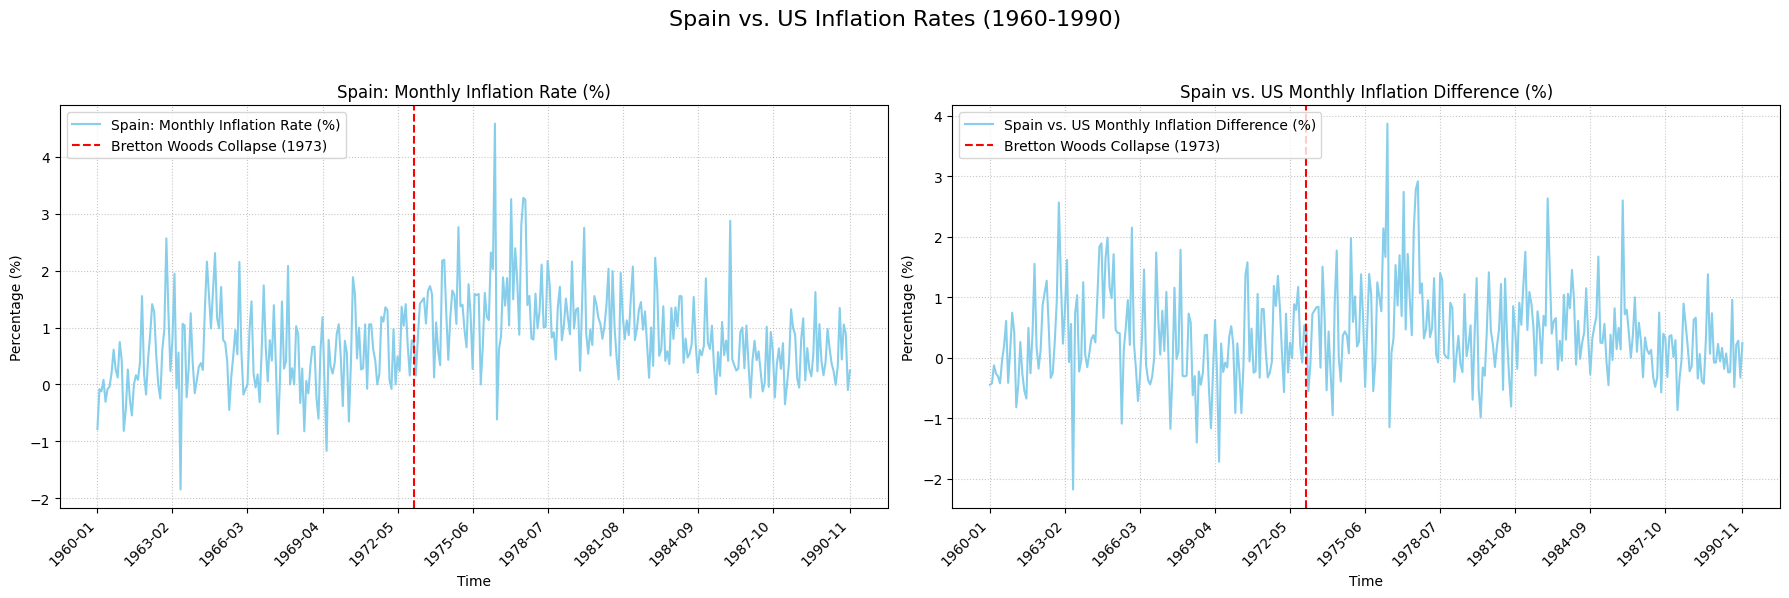

In [ ]:
# Define the period for filtering
start_period = pd.Period('1960-01', 'M')
end_period = pd.Period('1990-12', 'M')

# Ensure 'time' columns in both DataFrames are of Period type for consistent comparison
# spain['time'] is already Period type, so leave this commented out to avoid AttributeError
# spain['time'] = spain['time'].dt.to_period('M')
# US['time'] is datetime64[ns] and needs conversion to Period type for comparison.
# US['time'] = US['time'].dt.to_period('M') # This line is removed as US['time'] is already Period type

# Filter the DataFrames for the specified period
filtered_spain_inflation = spain[(spain['time'] >= start_period) & (spain['time'] <= end_period)].copy()
filtered_us_inflation = US[(US['time'] >= start_period) & (US['time'] <= end_period)].copy()

# Merge to calculate inflation difference
inflation_comparison = pd.merge(
    filtered_spain_inflation[['time', 'inflation_rate_%']],
    filtered_us_inflation[['time', 'inflation_rate_%']],
    on='time',
    suffixes=('_spain', '_us')
).copy()

inflation_comparison['inflation_diff_%'] = inflation_comparison['inflation_rate_%_spain'] - inflation_comparison['inflation_rate_%_us']

# Convert object columns to numeric, coercing errors to NaN
for col in ['inflation_rate_%']:
    if col in filtered_spain_inflation.columns:
        filtered_spain_inflation[col] = pd.to_numeric(filtered_spain_inflation[col], errors='coerce')
for col in ['inflation_rate_%_spain', 'inflation_rate_%_us', 'inflation_diff_%']:
    if col in inflation_comparison.columns:
        inflation_comparison[col] = pd.to_numeric(inflation_comparison[col], errors='coerce')


# Define the variables to plot
plot_vars_inflation = {
    'inflation_rate_%': 'Spain: Monthly Inflation Rate (%)',
    'inflation_diff_%': 'Spain vs. US Monthly Inflation Difference (%)'
}

# Create a figure and a set of subplots for inflation (1 row, 2 columns)
fig_inflation, axes_inflation = plt.subplots(nrows=1, ncols=2, figsize=(18, 6), sharex=True)
fig_inflation.suptitle('Spain vs. US Inflation Rates (1960-1990)', fontsize=16, y=1.02)

# Define the year 1973 for the vertical line
year_1973_period = pd.Period('1973-01', 'M') # Using January 1973 as the marker

# Plot inflation variables
for i, (col, title) in enumerate(plot_vars_inflation.items()):
    ax = axes_inflation[i]
    if col == 'inflation_rate_%':
        ax.plot(filtered_spain_inflation['time'].astype(str), filtered_spain_inflation[col], color='skyblue', label=title)
    else:
        ax.plot(inflation_comparison['time'].astype(str), inflation_comparison[col], color='skyblue', label=title)
    ax.set_ylabel('Percentage (%)')
    ax.set_title(title)
    ax.axvline(x=year_1973_period.strftime('%Y-%m'), color='red', linestyle='--', linewidth=1.5, label='Bretton Woods Collapse (1973)')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper left')
    ax.set_xlabel('Time')

# Improve x-axis tick readability for PeriodIndex
n_ticks = 10 # Number of ticks to display
tick_labels = filtered_spain_inflation['time'].iloc[::len(filtered_spain_inflation['time']) // n_ticks].astype(str)
tick_positions = np.linspace(0, len(filtered_spain_inflation) - 1, len(tick_labels), dtype=int)

for ax in axes_inflation:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    ax.tick_params(labelbottom=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

### 4.2.2, Industrial Production Analysis (Spain)
This section visualizes Spain's industrial production dynamics.

The 1x2 grid includes:

Monthly % Growth: Monthly percentage change in industrial production.
Year-over-Year % Growth: Percentage change in industrial production compared to the same month in the previous year.

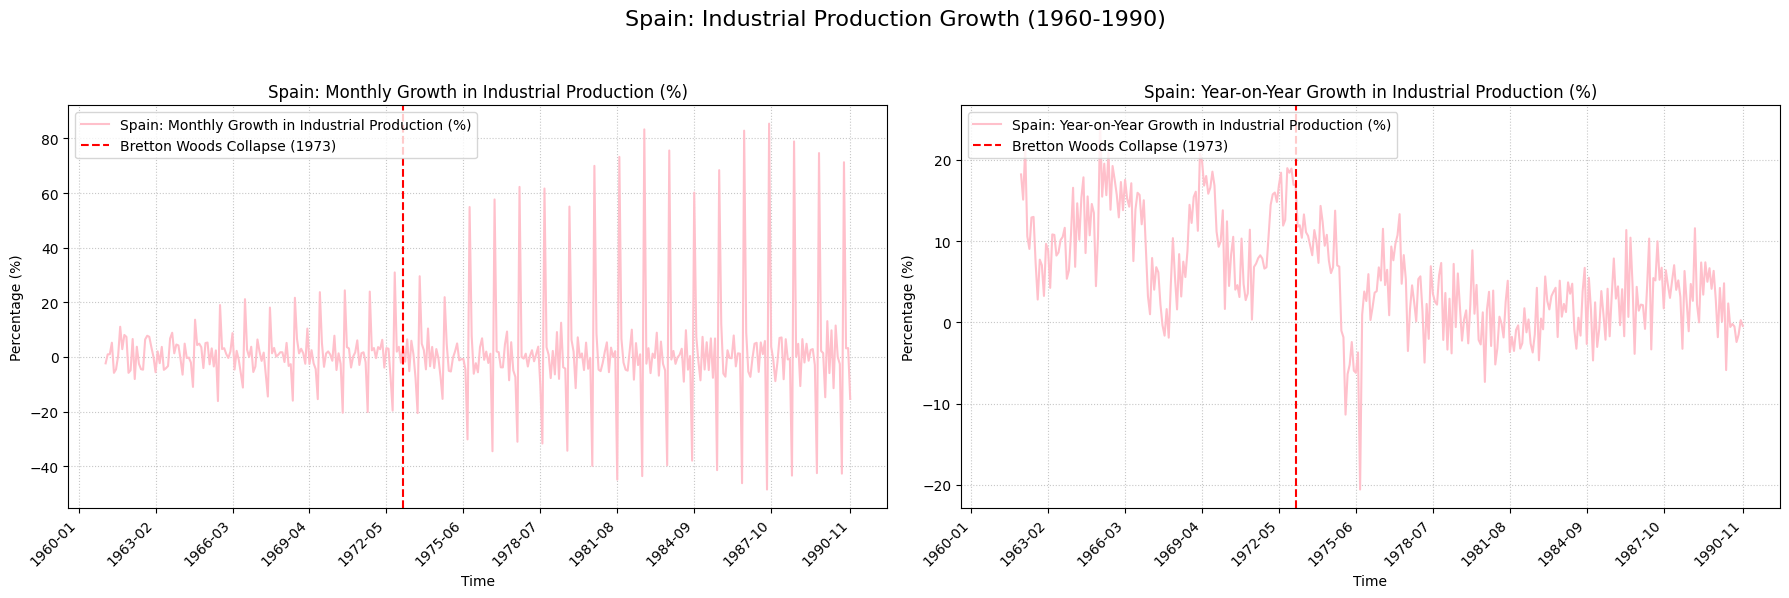

In [ ]:
# Define the period for filtering (same as previous cell to maintain context)
start_period = pd.Period('1960-01', 'M')
end_period = pd.Period('1990-12', 'M')

# Ensure 'time' column in 'spain' DataFrame is of Period type for consistent comparison
# This line is duplicated from the previous cell, but needed if this cell is run independently
# spain['time'] = spain['time'].dt.to_period('M') # This line is commented out as spain['time'] is already PeriodDtype.

# Filter the Spain DataFrame for industrial production
filtered_spain_industrial_production = spain[(spain['time'] >= start_period) & (spain['time'] <= end_period)].copy()

# Convert relevant columns to numeric, coercing errors to NaN
for col in ['gr_ind_prod_%', 'yr_on_yr_gr_ind_prod']:
    if col in filtered_spain_industrial_production.columns:
        filtered_spain_industrial_production[col] = pd.to_numeric(filtered_spain_industrial_production[col], errors='coerce')

# Define the variables to plot for industrial production
plot_vars_industrial_production = {
    'gr_ind_prod_%': 'Spain: Monthly Growth in Industrial Production (%)',
    'yr_on_yr_gr_ind_prod': 'Spain: Year-on-Year Growth in Industrial Production (%)'
}

# Create a figure and a set of subplots for industrial production (1 row, 2 columns)
fig_industrial_production, axes_industrial_production = plt.subplots(nrows=1, ncols=2, figsize=(18, 6), sharex=True)
fig_industrial_production.suptitle('Spain: Industrial Production Growth (1960-1990)', fontsize=16, y=1.02)

# Define the year 1973 for the vertical line
year_1973_period = pd.Period('1973-01', 'M') # Using January 1973 as the marker

# Plot industrial production variables
for i, (col, title) in enumerate(plot_vars_industrial_production.items()):
    ax = axes_industrial_production[i]
    ax.plot(filtered_spain_industrial_production['time'].astype(str), filtered_spain_industrial_production[col], color='pink', label=title)
    ax.set_ylabel('Percentage (%)')
    ax.set_title(title)
    ax.axvline(x=year_1973_period.strftime('%Y-%m'), color='red', linestyle='--', linewidth=1.5, label='Bretton Woods Collapse (1973)')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper left')
    ax.set_xlabel('Time')

# Improve x-axis tick readability for PeriodIndex (using filtered_spain_industrial_production)
n_ticks = 10 # Number of ticks to display
tick_labels_ip = filtered_spain_industrial_production['time'].iloc[::len(filtered_spain_industrial_production['time']) // n_ticks].astype(str)
tick_positions_ip = np.linspace(0, len(filtered_spain_industrial_production) - 1, len(tick_labels_ip), dtype=int)

for ax in axes_industrial_production:
    ax.set_xticks(tick_positions_ip)
    ax.set_xticklabels(tick_labels_ip, rotation=45, ha='right')
    ax.tick_params(labelbottom=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

### 4.2.3, Answers to the Questions
Q1: Why are results for monthly versus 12-monthly growth so different? Which is more useful? The monthly growth graph (left) shows extreme spikes reaching up to +80% and -40%, which are clearly driven by seasonal patterns in Spanish industrial production — factories regularly shut down and restart, creating artificial month-to-month swings that have nothing to do with the underlying economy. The 12-monthly graph (right) is far smoother, ranging between roughly -20% and +25%, because comparing each month to the same month a year earlier cancels out these seasonal effects. The 12-monthly measure is more useful as it reveals genuine economic trends, such as the clear slowdown in industrial growth after 1973 and the deep dip around 1974-75 following the oil crisis.

Q2: Why use monthly data rather than quarterly or annual? Monthly data gives us far more observations over the 1960-1990 period, which is essential for precisely identifying when volatility changed around the end of Bretton Woods in 1973. With quarterly or annual data we would lose the ability to pinpoint exactly when structural breaks occurred. Monthly data also better captures short-run fluctuations in inflation (visible in the left inflation graph) and exchange rates that would be averaged away in lower-frequency data.

## 4.3, Statistical Explanations for the Previous Graphs

### 4.3.1, Calculate Standard Deviations for Pre and Post Bretton Woods Periods
This section calculates the standard deviation for key economic indicators during two distinct periods:
*   **Pre-Bretton Woods**: December 1959 to June 1971
*   **Post-Bretton Woods**: March 1973 to December 1990

The indicators analyzed are:
*   Monthly % growth of the nominal exchange rate (`ER_Nom_Growth`)
*   Monthly % growth of the real exchange rate (`ER_Real_Growth`)
*   Monthly inflation rate for Spain (`Inflation_Spain`)
*   Difference between Spain and US monthly inflation (`Inflation_Diff`)
*   12-monthly industrial production growth (`PI_Growth_YoY`)

These figures are output in a contingency table, and later on visualised in a bar chart in 4.3.2.

In [ ]:
# Define the periods for before and after Bretton Woods
period_before_bw_end = pd.Period('1971-06', 'M')
period_after_bw_start = pd.Period('1973-03', 'M')

# Filter Spain data for both periods
spain_before_bw = spain[spain['time'] <= period_before_bw_end].copy()
spain_after_bw = spain[spain['time'] >= period_after_bw_start].copy()

# Filter US data for both periods (needed for inflation difference)
US_before_bw = US[US['time'] <= period_before_bw_end].copy()
US_after_bw = US[US['time'] >= period_after_bw_start].copy()

# Calculate inflation difference for both periods
inflation_comparison_before_bw = pd.merge(
    spain_before_bw[['time', 'inflation_rate_%']],
    US_before_bw[['time', 'inflation_rate_%']],
    on='time',
    suffixes=('_spain', '_us')
)
inflation_comparison_before_bw['inflation_diff_%'] = inflation_comparison_before_bw['inflation_rate_%_spain'] - inflation_comparison_before_bw['inflation_rate_%_us']

inflation_comparison_after_bw = pd.merge(
    spain_after_bw[['time', 'inflation_rate_%']],
    US_after_bw[['time', 'inflation_rate_%']],
    on='time',
    suffixes=('_spain', '_us')
)
inflation_comparison_after_bw['inflation_diff_%'] = inflation_comparison_after_bw['inflation_rate_%_spain'] - inflation_comparison_after_bw['inflation_rate_%_us']

# Define variables to calculate standard deviation for
variables = {
    'gr_nER_%': 'Monthly growth in nominal exchange rate',
    'gr_rER_%': 'Monthly growth in real exchange rate',
    'inflation_rate_%': 'Inflation rate (Spain)',
    'inflation_diff_%': 'Inflation difference (Spain vs. US)',
    'yr_on_yr_gr_ind_prod': '12-monthly industrial production growth'
}

# Ensure all relevant columns are numeric before calculating standard deviation
for df in [spain_before_bw, spain_after_bw]:
    for col in ['gr_nER_%', 'gr_rER_%', 'inflation_rate_%', 'yr_on_yr_gr_ind_prod']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

for df in [inflation_comparison_before_bw, inflation_comparison_after_bw]:
    for col in ['inflation_diff_%']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# Prepare a dictionary to store results
results = []

for var_key, var_name in variables.items():
    std_before = None
    std_after = None

    # Handle inflation_diff_% separately as it's in a different dataframe
    if var_key == 'inflation_diff_%':
        std_before = inflation_comparison_before_bw[var_key].std()
        std_after = inflation_comparison_after_bw[var_key].std()
    else:
        std_before = spain_before_bw[var_key].std()
        std_after = spain_after_bw[var_key].std()

    ratio = std_before / std_after if std_after != 0 else np.nan

    results.append({
        'Variable': var_name,
        'Std Dev Before BW (until 06/1971)': std_before,
        'Std Dev After BW (from 03/1973)': std_after,
        'Ratio (Before/After)': ratio
    })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Display the formatted table
print("Standard Deviations Before and After Bretton Woods for Spain:")
display(results_df.round(4))

Standard Deviations Before and After Bretton Woods for Spain:


,Variable,Std Dev Before BW (until 06/1971),Std Dev After BW (from 03/1973),Ratio (Before/After)
0,Monthly growth in nominal exchange rate,1.4188,2.5733,0.5513
1,Monthly growth in real exchange rate,1.4807,2.5364,0.5838
2,Inflation rate (Spain),0.7299,0.7419,0.9838
3,Inflation difference (Spain vs. US),0.7883,0.7482,1.0536
4,12-monthly industrial production growth,5.7063,4.9363,1.1560


### 4.3.2, Standard Deviation Comparison (Pre vs. Post Bretton Woods)

This bar chart compares the volatility (measured by standard deviation) of key economic indicators before and after the collapse of the Bretton Woods system.

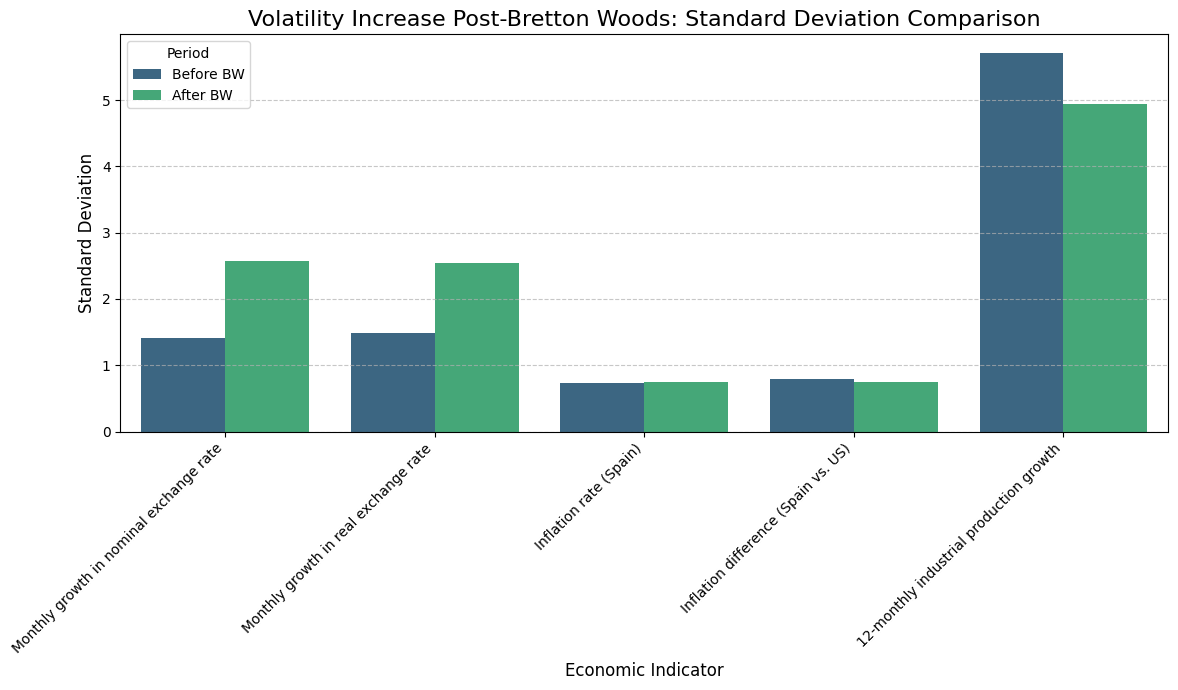

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # Import seaborn for plotting

# Ensure results_df is available, if not, recreate it from the results_list
# Assuming results_df is already in the kernel from previous execution.

# Prepare data for plotting
# Melt the DataFrame to have 'Period' as a column for easier plotting
plot_df = results_df.melt(id_vars='Variable',
                          value_vars=['Std Dev Before BW (until 06/1971)', 'Std Dev After BW (from 03/1973)'],
                          var_name='Period', value_name='Standard Deviation')

# Rename periods for better readability in the plot
plot_df['Period'] = plot_df['Period'].replace({
    'Std Dev Before BW (until 06/1971)': 'Before BW',
    'Std Dev After BW (from 03/1973)': 'After BW'
})

plt.figure(figsize=(12, 7))
# Create the grouped bar chart
sns.barplot(x='Variable', y='Standard Deviation', hue='Period', data=plot_df, palette='viridis')

plt.title('Volatility Increase Post-Bretton Woods: Standard Deviation Comparison', fontsize=16)
plt.xlabel('Economic Indicator', fontsize=12)
plt.ylabel('Standard Deviation', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.legend(title='Period')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Q: Why exclude data from 07/1971 - 02/1973?

This period is a transition phase between the two regimes — the US suspended gold convertibility in August 1971 but countries had not yet fully moved to floating exchange rates. The Smithsonian Agreement of December 1971 attempted to maintain a modified fixed rate system, which only fully collapsed in March 1973. Including this transitional period would blur the comparison between the two distinct regimes, as exchange rates were neither fully fixed nor freely floating. Excluding it gives a cleaner before-and-after comparison.

### 4.3.3, Yearly Volatility Trends (1960-1990)

This section analyzes how volatility evolved year-by-year.

**Each plot includes:**
1.  **Yearly Standard Deviation**: One point per calendar year representing the volatility within that specific year.
2.  **Period Benchmarks**: Horizontal lines representing the average standard deviation for the Pre-BW and Post-BW periods calculated previously.
3.  **Bretton Woods Exit**: A vertical dashed red line standing at 1973 for Spain leaving BW; a vertical dashed purple line standing at 1971 for the US leaving BW.

In [ ]:
def plot_yearly_std(ax, df_input, value_col, title, ylabel, var_name_for_results, results_df):
    # Ensure 'time' column is in Period/Datetime format if not already
    if 'time' in df_input.columns and not isinstance(df_input['time'].iloc[0], pd.Period):
        df_input['time'] = pd.to_datetime(df_input['time']).dt.to_period('M')

    # Calculate yearly standard deviation, handling potential NaNs
    df_input_copy = df_input.copy()
    df_input_copy['year'] = df_input_copy['time'].dt.year
    yearly_std = df_input_copy.groupby('year')[value_col].std().reset_index()

    # Plot yearly standard deviation
    ax.plot(yearly_std['year'], yearly_std[value_col], marker='o', linestyle='-', color='darkgreen', label='Yearly Std Dev')
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)

    # Add vertical line for Bretton Woods collapse (1973)
    ax.axvline(x=1973, color='red', linestyle='--', linewidth=1.5, label='Bretton Woods Collapse (1973)')
    # Add vertical line for US leaving Bretton Woods (1971)
    ax.axvline(x=1971, color='purple', linestyle=':', linewidth=1.5, label='US Leaves Bretton Woods (1971)')

    # Get pre and post BW standard deviations from results_df
    row = results_df[results_df['Variable'] == var_name_for_results]
    if not row.empty:
        std_before = row['Std Dev Before BW (until 06/1971)'].iloc[0]
        std_after = row['Std Dev After BW (from 03/1973)'].iloc[0]

        # Define years for plotting horizontal lines based on analysis period (1960-1990)
        # Note: The 'before' period technically ends in 1971-06, and 'after' starts in 1973-03.
        # For yearly plots, we approximate this to years 1960-1971 and 1973-1990.
        ax.hlines(std_before, xmin=1960, xmax=1971, color='blue', linestyle='-.', label=f'Overall Std Dev Before BW ({std_before:.2f})')
        ax.hlines(std_after, xmin=1973, xmax=1990, color='orange', linestyle='-.', label=f'Overall Std Dev After BW ({std_after:.2f})')

    ax.legend(loc='upper left')
    # Add both general grid and a more prominent x-axis grid
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.xaxis.grid(True, linestyle='-', alpha=0.9, color='gray') # More prominent x-axis grid

    # Set x-ticks to display every year
    if not yearly_std.empty:
        all_years = yearly_std['year'].unique()
        ax.set_xticks(all_years)
        ax.set_xticklabels(all_years.astype(str), rotation=45, ha='right')

    ax.tick_params(axis='x', rotation=45)

def plot_regression_with_fits(ax, X, Y, df_source, title, ylabel, linear_color='red', quadratic_color='orange'):
    # Plot scatter points with colors based on year
    # We need to ensure X and Y align with df_source for year information
    # Assuming X and Y are Series with an index that aligns with df_source's index
    for idx in X.index:
        year = df_source.loc[idx, 'year']
        if year <= 1971:
            ax.scatter(X.loc[idx], Y.loc[idx], color='skyblue', alpha=0.6)
        elif year == 1972:
            ax.scatter(X.loc[idx], Y.loc[idx], color='grey', alpha=0.6)
        else:
            ax.scatter(X.loc[idx], Y.loc[idx], color='coral', alpha=0.6)

    # Add dummy points for custom legend entries
    ax.scatter([], [], color='skyblue', label='Data <= 1971')
    ax.scatter([], [], color='grey', label='Data 1972 (Transition)')
    ax.scatter([], [], color='coral', label='Data > 1971')

    # Linear fit
    X_linear = sm.add_constant(X)
    model_linear = sm.OLS(Y, X_linear, missing='drop')
    results_linear = model_linear.fit()
    X_pred_linear = np.linspace(X.min(), X.max(), 100)
    X_pred_linear_sm = sm.add_constant(X_pred_linear)
    ax.plot(X_pred_linear, results_linear.predict(X_pred_linear_sm), color=linear_color, label='Linear Fit')

    # Quadratic fit
    X_quad = pd.DataFrame({'const': 1, 'X': X, 'X_sq': X**2})
    model_quad = sm.OLS(Y, X_quad, missing='drop')
    results_quad = model_quad.fit()
    X_pred_quad_df = pd.DataFrame({'const': 1, 'X': X_pred_linear, 'X_sq': X_pred_linear**2})
    ax.plot(X_pred_linear, results_quad.predict(X_pred_quad_df), color=quadratic_color, label='Quadratic Fit')

    ax.set_title(title)
    ax.set_xlabel('Std Dev of Real Exchange Rate Growth')
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper left') # Adjust legend location
    ax.grid(True, linestyle=':', alpha=0.7)

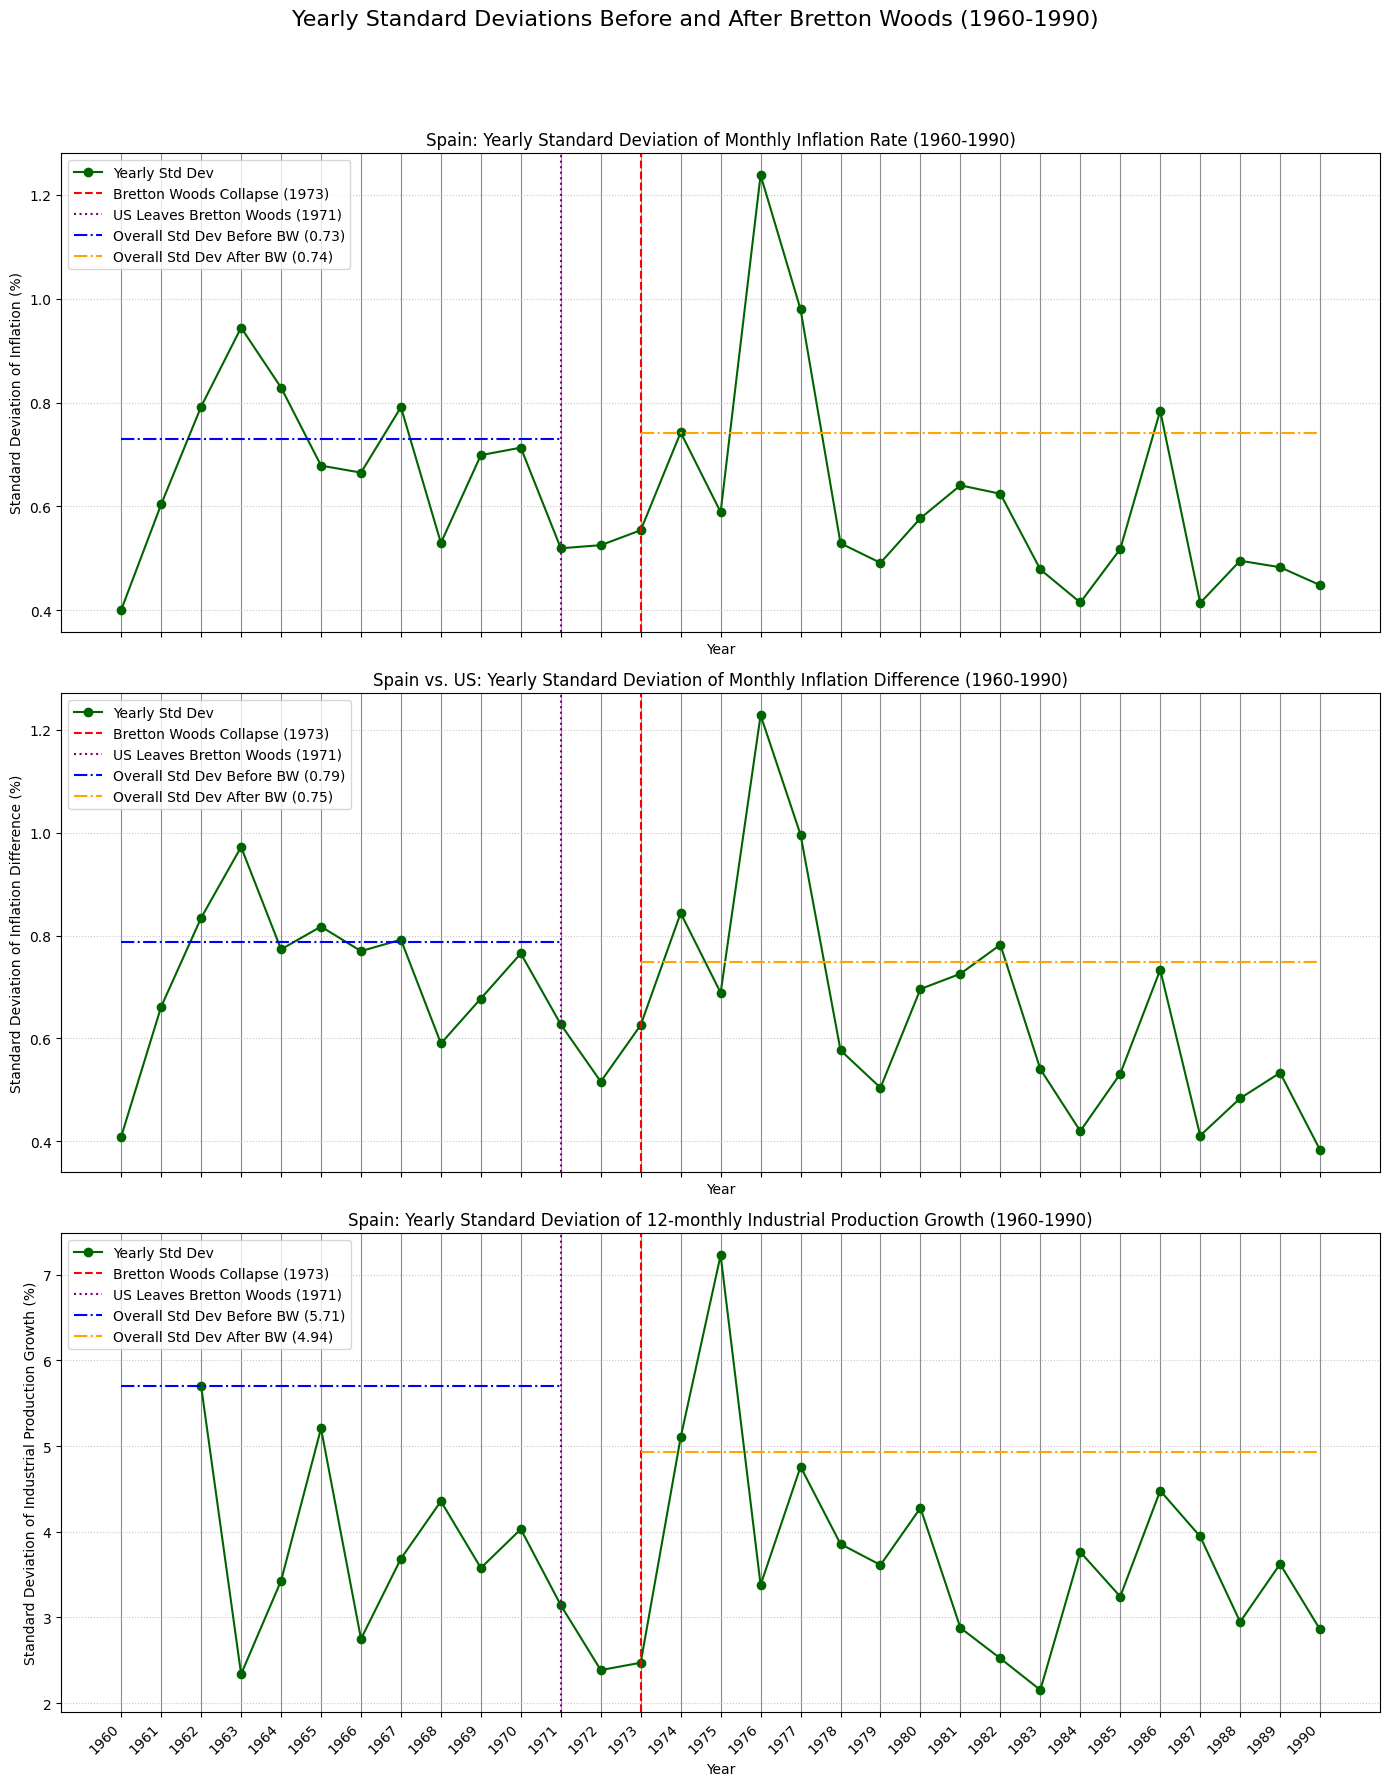

In [ ]:
# Define inflation_comparison_full to ensure it's available
inflation_comparison_full = pd.merge(
    spain[['time', 'inflation_rate_%']],
    US[['time', 'inflation_rate_%']],
    on='time',
    suffixes=('_spain', '_us')
).copy()
inflation_comparison_full['inflation_diff_%'] = inflation_comparison_full['inflation_rate_%_spain'] - inflation_comparison_full['inflation_rate_%_us']

# Create a figure with 3 subplots arranged vertically
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 18), sharex=True)
fig.suptitle('Yearly Standard Deviations Before and After Bretton Woods (1960-1990)', fontsize=16, y=1.02)

# Plot 1: Monthly Inflation Rate (Spain)
plot_yearly_std(
    axes[0],
    filtered_spain,
    'inflation_rate_%',
    'Spain: Yearly Standard Deviation of Monthly Inflation Rate (1960-1990)',
    'Standard Deviation of Inflation (%)',
    'Inflation rate (Spain)',
    results_df
)

# Plot 2: Inflation Difference (Spain vs. US)
plot_yearly_std(
    axes[1],
    inflation_comparison_full,
    'inflation_diff_%',
    'Spain vs. US: Yearly Standard Deviation of Monthly Inflation Difference (1960-1990)',
    'Standard Deviation of Inflation Difference (%)',
    'Inflation difference (Spain vs. US)',
    results_df
)

# Plot 3: 12-monthly Industrial Production Growth (Spain)
plot_yearly_std(
    axes[2],
    filtered_spain,
    'yr_on_yr_gr_ind_prod',
    'Spain: Yearly Standard Deviation of 12-monthly Industrial Production Growth (1960-1990)',
    'Standard Deviation of Industrial Production Growth (%)',
    '12-monthly industrial production growth',
    results_df
)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

## 4.4, Regression Analysis

### 4.4.1, Half-Year Windows
This section calculates the standard deviation for key economic variables within specific 6-month windows (the 1st and 2nd halves of a year) from 1960 to 1990. This allows for a more granular look at how volatility changed within each year.

In [ ]:
inflation_comparison_full = pd.merge(
    spain[['time', 'inflation_rate_%']],
    US[['time', 'inflation_rate_%']],
    on='time',
    suffixes=('_spain', '_us')
).copy()
inflation_comparison_full['inflation_diff_%'] = inflation_comparison_full['inflation_rate_%_spain'] - inflation_comparison_full['inflation_rate_%_us']

In [ ]:
# Ensure 'time' columns are in Period[M] format for consistent grouping
# spain and US dataframes are already in the kernel with 'time' as Period[M]
# inflation_comparison_full dataframe is also in the kernel with 'time' as Period[M]

# Select relevant columns from spain
spain_vars = spain[['time', 'gr_rER_%', 'inflation_rate_%', 'yr_on_yr_gr_ind_prod']].copy()

# Select relevant columns from inflation_comparison_full
inflation_diff_vars = inflation_comparison_full[['time', 'inflation_diff_%']].copy()

# Merge them on 'time' to get all variables in a single DataFrame
df_for_std = pd.merge(spain_vars, inflation_diff_vars, on='time', how='inner')

# Convert relevant columns to numeric, coercing errors to NaN
for col in ['gr_rER_%', 'inflation_rate_%', 'yr_on_yr_gr_ind_prod', 'inflation_diff_%']:
    df_for_std[col] = pd.to_numeric(df_for_std[col], errors='coerce')

# Drop rows with NaN in any of the critical columns before calculating std
# This ensures that standard deviations are calculated only for complete 6-month periods
df_for_std.dropna(subset=['gr_rER_%', 'inflation_rate_%', 'yr_on_yr_gr_ind_prod', 'inflation_diff_%'], inplace=True)

# Create grouping keys for 6-month periods (Jan-Jun is half_year=1, Jul-Dec is half_year=2)
df_for_std['year'] = df_for_std['time'].dt.year
df_for_std['month'] = df_for_std['time'].dt.month
df_for_std['half_year'] = df_for_std['month'].apply(lambda x: 1 if x <= 6 else 2)

# Calculate 6-month standard deviations for each variable
std_dev_6month = df_for_std.groupby(['year', 'half_year'])[['gr_rER_%', 'inflation_rate_%', 'inflation_diff_%', 'yr_on_yr_gr_ind_prod']].std().reset_index()

# Rename columns for clarity
std_dev_6month.rename(columns={
    'gr_rER_%': 'std_gr_rER',
    'inflation_rate_%': 'std_inflation_spain',
    'inflation_diff_%': 'std_inflation_diff',
    'yr_on_yr_gr_ind_prod': 'std_yr_on_yr_gr_ind_prod'
}, inplace=True)

print("First 5 rows of 6-month standard deviations:")
display(std_dev_6month.head())

First 5 rows of 6-month standard deviations:


,year,half_year,std_gr_rER,std_inflation_spain,std_inflation_diff,std_yr_on_yr_gr_ind_prod
0,1962,1,0.558347,0.587396,0.564962,4.710191
1,1962,2,1.073079,1.012134,1.095935,3.685094
2,1963,1,1.286745,1.245621,1.279556,2.441701
3,1963,2,0.614453,0.576007,0.620854,2.464016
4,1964,1,0.389706,0.513965,0.394450,3.728271


### 4.4.2, OLS Regressions
In this step, we examine the relationship between real exchange rate volatility and other economic volatilities using Ordinary Least Squares (OLS) regressions. We use the 6-month standard deviations as our data points.

**Independent Variable (X):** 6-month standard deviation of Real Exchange Rate Growth.

**Dependent Variables (Y):**
1.  6-month standard deviation of Spain's Inflation
2.  6-month standard deviation of the Inflation Difference
3.  6-month standard deviation of Industrial Production Growth

In [ ]:
import statsmodels.api as sm

# Prepare the data for regression
# Filter out NaN values that might arise from earlier calculations before regression
std_dev_6month_clean = std_dev_6month.dropna(subset=['std_gr_rER', 'std_inflation_spain', 'std_inflation_diff', 'std_yr_on_yr_gr_ind_prod']).copy()

# Define the independent variable (X) and dependent variables (Y)
X = std_dev_6month_clean['std_gr_rER']

# Regression 1: Std Dev of Spain's Inflation Rate
Y1 = std_dev_6month_clean['std_inflation_spain']
X_sm = sm.add_constant(X) # Adds a constant term to the predictor
model1 = sm.OLS(Y1, X_sm, missing='drop')
results1 = model1.fit()
print("\nRegression 1: Std Dev of Spain's Inflation Rate vs. Std Dev of Real Exchange Rate Growth")
print(results1.summary())

# Regression 2: Std Dev of Inflation Difference (Spain vs. US)
Y2 = std_dev_6month_clean['std_inflation_diff']
model2 = sm.OLS(Y2, X_sm, missing='drop')
results2 = model2.fit()
print("\nRegression 2: Std Dev of Inflation Difference vs. Std Dev of Real Exchange Rate Growth")
print(results2.summary())

# Regression 3: Std Dev of Spain's 12-monthly Industrial Production Growth
Y3 = std_dev_6month_clean['std_yr_on_yr_gr_ind_prod']
model3 = sm.OLS(Y3, X_sm, missing='drop')
results3 = model3.fit()
print("\nRegression 3: Std Dev of Spain's 12-monthly Industrial Production Growth vs. Std Dev of Real Exchange Rate Growth")
print(results3.summary())


Regression 1: Std Dev of Spain's Inflation Rate vs. Std Dev of Real Exchange Rate Growth
                             OLS Regression Results                            
Dep. Variable:     std_inflation_spain   R-squared:                       0.111
Model:                             OLS   Adj. R-squared:                  0.095
Method:                  Least Squares   F-statistic:                     7.002
Date:                 Sun, 29 Mar 2026   Prob (F-statistic):             0.0106
Time:                         08:55:38   Log-Likelihood:                 1.7907
No. Observations:                   58   AIC:                            0.4186
Df Residuals:                       56   BIC:                             4.540
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

### 4.4.3, Scatterplots and Fitted lines/Curves
This section visualizes the relationship between Real Exchange Rate volatility and other economic volatilities using 6-month standard deviations.

Color Coding:

1. Blue: Pre-Bretton Woods (Up to June 1971)
2. Coral Orange: Post-Bretton Woods (From March 1973)
3. Grey: Transition Period (July 1971 - February 1973)

Each plot includes both a linear and a quadratic (second-degree) line of best fit to explore the nature of the relationship.

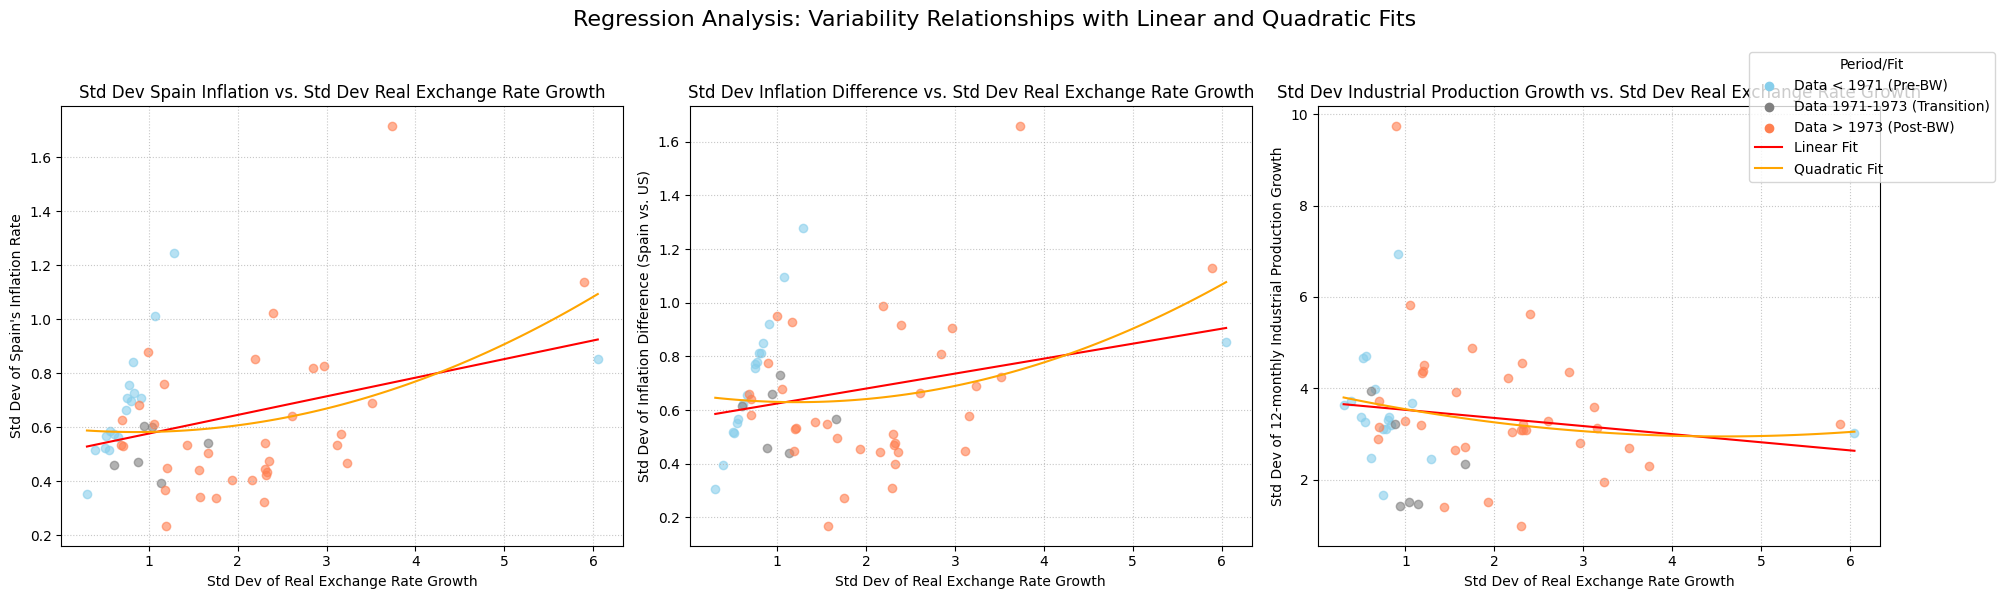

In [ ]:
import statsmodels.api as sm

def plot_regression_with_fits(ax, X, Y, df_source, title, ylabel, linear_color='red', quadratic_color='orange'):
    # Plot scatter points with colors based on year
    # We need to ensure X and Y align with df_source for year information
    # Assuming X and Y are Series with an index that aligns with df_source's index
    for idx in X.index:
        year = df_source.loc[idx, 'year']
        if year < 1971:
            ax.scatter(X.loc[idx], Y.loc[idx], color='skyblue', alpha=0.6)
        elif 1971 <= year <= 1973:
            ax.scatter(X.loc[idx], Y.loc[idx], color='grey', alpha=0.6)
        else:
            ax.scatter(X.loc[idx], Y.loc[idx], color='coral', alpha=0.6)

    # Add dummy points for custom legend entries
    # These labels will be used for the unified legend
    ax.scatter([], [], color='skyblue', label='Data < 1971 (Pre-BW)')
    ax.scatter([], [], color='grey', label='Data 1971-1973 (Transition)')
    ax.scatter([], [], color='coral', label='Data > 1973 (Post-BW)')

    # Linear fit
    X_linear = sm.add_constant(X) # Adds a constant term to the predictor
    model_linear = sm.OLS(Y, X_linear, missing='drop')
    results_linear = model_linear.fit()
    X_pred_linear = np.linspace(X.min(), X.max(), 100)
    X_pred_linear_sm = sm.add_constant(X_pred_linear)
    ax.plot(X_pred_linear, results_linear.predict(X_pred_linear_sm), color=linear_color, label='Linear Fit')

    # Quadratic fit
    X_quad = pd.DataFrame({'const': 1, 'X': X, 'X_sq': X**2})
    model_quad = sm.OLS(Y, X_quad, missing='drop')
    results_quad = model_quad.fit()
    X_pred_quad_df = pd.DataFrame({'const': 1, 'X': X_pred_linear, 'X_sq': X_pred_linear**2})
    ax.plot(X_pred_linear, results_quad.predict(X_pred_quad_df), color=quadratic_color, label='Quadratic Fit')

    ax.set_title(title)
    ax.set_xlabel('Std Dev of Real Exchange Rate Growth')
    ax.set_ylabel(ylabel)
    # ax.legend(loc='upper left') # Removed individual legend for unified figure legend
    ax.grid(True, linestyle=':', alpha=0.7)

# Create a figure with 3 subplots arranged horizontally
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6), sharex=True) # Changed to 1 row, 3 columns
fig.suptitle('Regression Analysis: Variability Relationships with Linear and Quadratic Fits', fontsize=16, y=1.02)

# Assuming X, Y1, Y2, Y3, results1, results2, results3 are already defined from previous cells
# (X is std_gr_rER, Y1 is std_inflation_spain, Y2 is std_inflation_diff, Y3 is std_yr_on_yr_gr_ind_prod)

# Regression 1 plot: Std Dev of Spain's Inflation Rate
plot_regression_with_fits(axes[0], X, Y1, std_dev_6month_clean,
                        "Std Dev Spain Inflation vs. Std Dev Real Exchange Rate Growth",
                        "Std Dev of Spain's Inflation Rate")

# Regression 2 plot: Std Dev of Inflation Difference (Spain vs. US)
plot_regression_with_fits(axes[1], X, Y2, std_dev_6month_clean,
                        "Std Dev Inflation Difference vs. Std Dev Real Exchange Rate Growth",
                        "Std Dev of Inflation Difference (Spain vs. US)")

# Regression 3 plot: Std Dev of Spain's 12-monthly Industrial Production Growth
plot_regression_with_fits(axes[2], X, Y3, std_dev_6month_clean,
                        "Std Dev Industrial Production Growth vs. Std Dev Real Exchange Rate Growth",
                        "Std Dev of 12-monthly Industrial Production Growth")

# Collect legend handles and labels from one of the subplots to create a unified legend
# Using axes[0] for this purpose as all plots use the same legend elements for clarity
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Period/Fit', loc='upper right', bbox_to_anchor=(1.0, 0.95), borderaxespad=0.)

plt.tight_layout(rect=[0, 0.03, 0.95, 0.98]) # Adjust tight_layout to make space for the figure legend
plt.show()


### 4.4.4, Answers to the Question
Q: What regressions have been implicitly run to produce the linear and quadratic lines of best fit?

The linear line of best fit implicitly runs an OLS regression of the form: Y = β₀ + β₁X, where Y is the dependent variable (e.g. standard deviation of inflation) and X is the standard deviation of real exchange rate growth. The quadratic line of best fit implicitly runs: Y = β₀ + β₁X + β₂X², where X² is the squared term of the independent variable. This is still a linear regression in the coefficients — it is estimated by OLS by simply adding X² as an additional regressor alongside X.

# 5, Extensions

## 5.1, Studying Levels VS Volatility

### 5.1.1, Average Level Analysis: Pre vs. Post Bretton Woods
This section calculates the mean (average) levels of the following key economic indicators for the two primary regimes:
*   **Pre-Bretton Woods**: Dec 1959 - Jun 1971
*   **Post-Bretton Woods**: Mar 1973 - Dec 1990

**Variables Analyzed:**
*   Nominal exchange rate level (Pesetas/USD)
*   Real exchange rate index
*   Monthly inflation rate for Spain
*   12-monthly industrial production growth

The results are presented in a formatted table with pre/post columns and ratio/difference columns, followed by bar charts for visual comparison.

In [ ]:
# Define the periods
period_pre_bw_start = pd.Period('1959-12', 'M')
period_pre_bw_end = pd.Period('1971-06', 'M')

period_post_bw_start = pd.Period('1973-03', 'M')
period_post_bw_end = pd.Period('1990-12', 'M')

# Ensure 'time' column in 'spain' DataFrame is of Period type for consistent comparison
# This step might be redundant if already done, but ensures consistency.
# spain['time'] = spain['time'].dt.to_period('M')

# Filter Spain data for both periods
spain_pre_bw_avg = spain[(spain['time'] >= period_pre_bw_start) & (spain['time'] <= period_pre_bw_end)].copy()
spain_post_bw_avg = spain[(spain['time'] >= period_post_bw_start) & (spain['time'] <= period_post_bw_end)].copy()

# Define variables to calculate mean for
variables_for_mean_analysis = {
    'ER_per$': 'Nominal Exchange Rate Level (Pesetas/USD)',
    'rER_index': 'Real Exchange Rate Index',
    'inflation_rate_%': 'Monthly Inflation Rate (Spain)',
    'yr_on_yr_gr_ind_prod': '12-monthly Industrial Production Growth'
}

# Ensure all relevant columns are numeric before calculating means
for df_temp in [spain_pre_bw_avg, spain_post_bw_avg]:
    for col in variables_for_mean_analysis.keys():
        if col in df_temp.columns:
            df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

# Prepare a list to store results
mean_results = []

for var_key, var_name in variables_for_mean_analysis.items():
    mean_pre = spain_pre_bw_avg[var_key].mean()
    mean_post = spain_post_bw_avg[var_key].mean()

    # Calculate difference and ratio, handling potential division by zero for ratio
    difference = mean_post - mean_pre
    ratio = mean_post / mean_pre if mean_pre != 0 else float('inf') # Use inf for division by zero

    mean_results.append({
        'Variable': var_name,
        'Mean Pre-BW (Dec 1959 - Jun 1971)': mean_pre,
        'Mean Post-BW (Mar 1973 - Dec 1990)': mean_post,
        'Difference (Post - Pre)': difference,
        'Ratio (Post / Pre)': ratio
    })

# Create a DataFrame from the results
mean_results_df = pd.DataFrame(mean_results)

print("Average Levels of Key Economic Indicators (Pre vs. Post Bretton Woods):")
display(mean_results_df.round(4))

Average Levels of Key Economic Indicators (Pre vs. Post Bretton Woods):


,Variable,Mean Pre-BW (Dec 1959 - Jun 1971),Mean Post-BW (Mar 1973 - Dec 1990),Difference (Post - Pre),Ratio (Post / Pre)
0,Nominal Exchange Rate Level (Pesetas/USD),63.1655,100.8266,37.6612,1.5962
1,Real Exchange Rate Index,2.2309,1.4728,-0.7581,0.6602
2,Monthly Inflation Rate (Spain),0.4789,1.0037,0.5247,2.0957
3,12-monthly Industrial Production Growth,10.5399,2.5836,-7.9563,0.2451


### 5.1.2, Visualization of Average Levels (Pre vs. Post Bretton Woods)

This plot visualizes the average levels calculated in the previous step, providing a quick comparison of economic conditions before and after the Bretton Woods system.

/tmp/ipykernel_9480/122294958.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Mean Value', data=plot_data, palette=[color_pre, color_post], ax=ax)
/tmp/ipykernel_9480/122294958.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Mean Value', data=plot_data, palette=[color_pre, color_post], ax=ax)
/tmp/ipykernel_9480/122294958.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Mean Value', data=plot_data, palette=[color_pre, color_post], ax=ax)
/tmp/ipykernel_9480/122294958.py:24: FutureWar

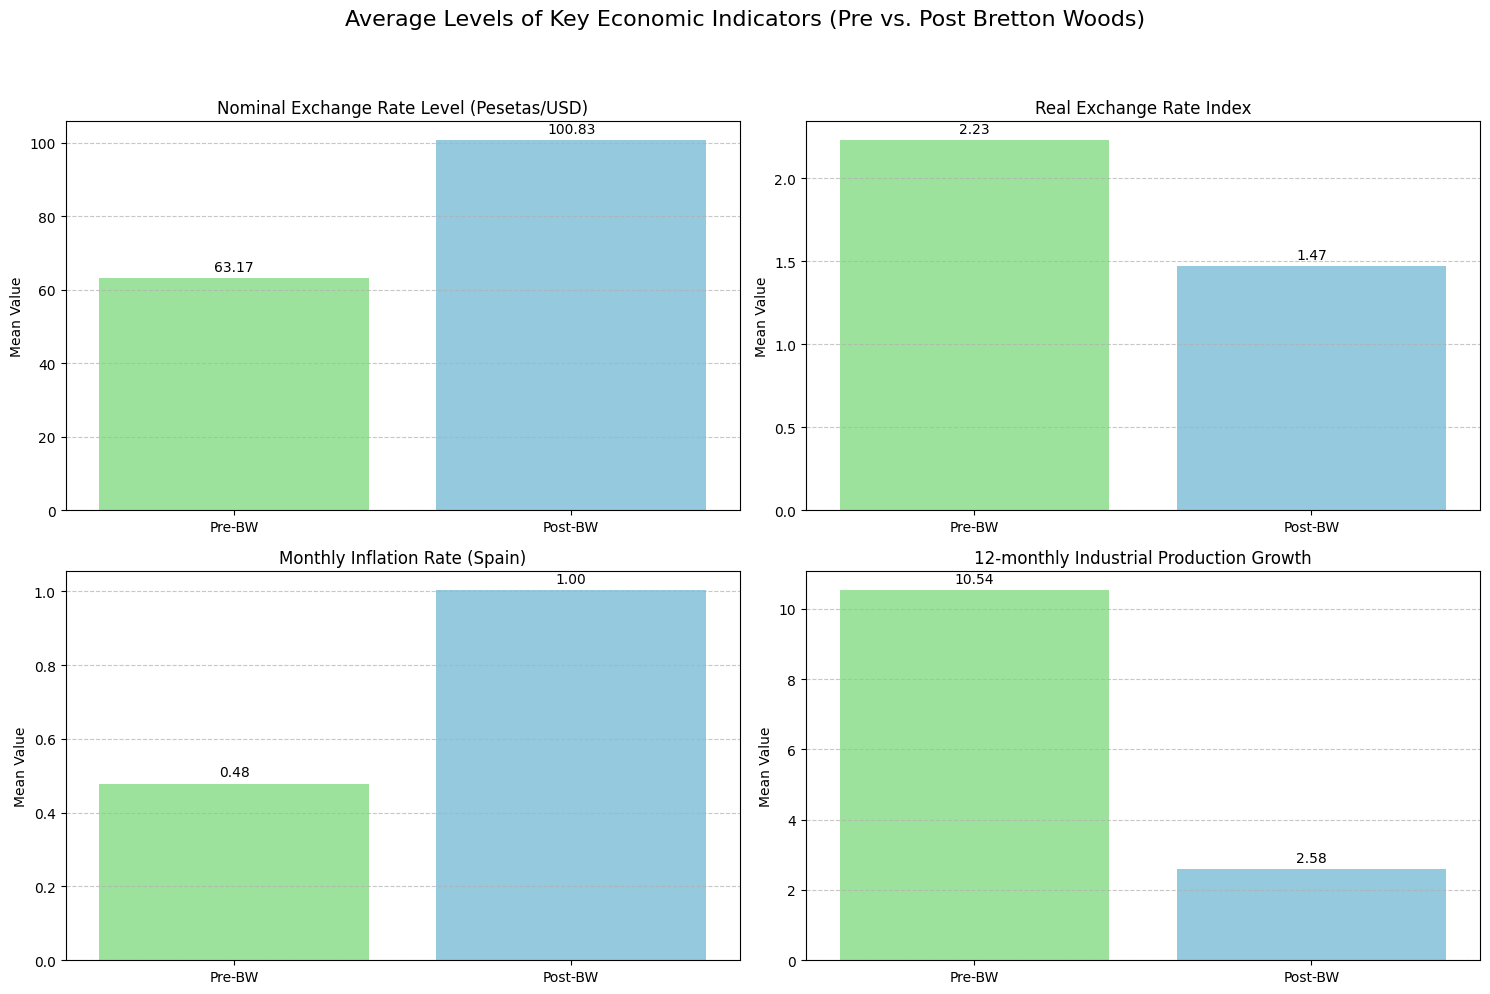

In [ ]:
# Create a figure and a set of subplots in a 2x2 matrix
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.suptitle('Average Levels of Key Economic Indicators (Pre vs. Post Bretton Woods)', fontsize=16, y=1.02)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Define colors
color_pre = 'lightgreen'
color_post = 'skyblue'

for i, row in mean_results_df.iterrows():
    ax = axes[i]
    variable_name = row['Variable']
    mean_pre = row['Mean Pre-BW (Dec 1959 - Jun 1971)']
    mean_post = row['Mean Post-BW (Mar 1973 - Dec 1990)']

    # Create a DataFrame for plotting this specific variable
    plot_data = pd.DataFrame({
        'Period': ['Pre-BW', 'Post-BW'],
        'Mean Value': [mean_pre, mean_post]
    })

    sns.barplot(x='Period', y='Mean Value', data=plot_data, palette=[color_pre, color_post], ax=ax)

    ax.set_title(variable_name, fontsize=12)
    ax.set_xlabel('') # Remove x-label as 'Period' is self-explanatory
    ax.set_ylabel('Mean Value')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10, padding=3)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

### 5.1.3, Sensitivity Analysis: Progressively Longer Windows around 1973

This section examines the robustness of our average level comparisons by using progressively longer time windows around the March 1973 Bretton Woods exit date. This helps to see how the choice of period length influences the observed differences between the pre and post regimes.

We calculate average levels for windows of $\pm$1 year, $\pm$3 years, and $\pm$5 years around the transition. A table summarizes these results, and a line plot shows the trend of post-1973 averages as the window size increases. Meaning: the mean values for different lengths of time windows are shown in a contingency table. Then, we demonstrate the change in "the difference between the mean values" with "length of time window" in a matrix of 4 line plots.

In [ ]:
# Define the Bretton Woods exit date for Spain as March 1973
bretton_woods_exit_date_spain = pd.Period('1973-03', 'M')

# Define the window lengths in years
window_lengths = [1, 3, 5]

# Define the variables to analyze
analysis_variables = {
    'ER_per$': 'Nominal Exchange Rate (peseta/USD)',
    'rER_index': 'Real Exchange Rate Index',
    'inflation_rate_%': 'Inflation Rate (% / month)',
    'yr_on_yr_gr_ind_prod': 'Year-on-Year Industrial Production Growth (%)'
}

# Create an empty list to store results
results_list = []

# Ensure relevant columns are numeric in the spain DataFrame
for col in analysis_variables.keys():
    if col in spain.columns:
        spain[col] = pd.to_numeric(spain[col], errors='coerce')

# Ensure 'time' column in 'spain' DataFrame is of Period type for consistent comparison
# spain['time'] = spain['time'].dt.to_period('M') # This line is commented out as it is redundant and causes an AttributeError

for window_years in window_lengths:
    # Convert the Period to a Timestamp for DateOffset calculations
    bw_exit_timestamp = bretton_woods_exit_date_spain.to_timestamp()

    # Define pre-Bretton Woods period using Timestamp and DateOffset
    start_pre_timestamp = bw_exit_timestamp - pd.DateOffset(years=window_years)
    end_pre_timestamp = bw_exit_timestamp - pd.DateOffset(months=1)

    # Define post-Bretton Woods period using Timestamp and DateOffset
    start_post_timestamp = bw_exit_timestamp + pd.DateOffset(months=1)
    end_post_timestamp = bw_exit_timestamp + pd.DateOffset(years=window_years)

    # Convert Timestamps back to Periods for filtering with spain['time']
    start_pre_period_P = start_pre_timestamp.to_period('M')
    end_pre_period_P = end_pre_timestamp.to_period('M')
    start_post_period_P = start_post_timestamp.to_period('M')
    end_post_period_P = end_post_timestamp.to_period('M')


    for var_col, var_name in analysis_variables.items():
        # Filter data for pre-period
        pre_data = spain[(spain['time'] >= start_pre_period_P) & (spain['time'] <= end_pre_period_P)]
        pre_avg = pre_data[var_col].mean()

        # Filter data for post-period
        post_data = spain[(spain['time'] >= start_post_period_P) & (spain['time'] <= end_post_period_P)]
        post_avg = post_data[var_col].mean()

        results_list.append({
            'Window (Years)': window_years,
            'Variable': var_name,
            'Period': 'Pre-Bretton Woods (Avg)',
            'Value': pre_avg
        })
        results_list.append({
            'Window (Years)': window_years,
            'Variable': var_name,
            'Period': 'Post-Bretton Woods (Avg)',
            'Value': post_avg
        })

# Create a DataFrame from the results list
df_results = pd.DataFrame(results_list)

# Pivot the DataFrame to create a contingency table
contingency_table = df_results.pivot_table(index='Variable', columns=['Window (Years)', 'Period'], values='Value')

print("Contingency Table of Average Levels Before and After Spain's Bretton Woods Exit (March 1973):")
display(contingency_table.round(4))

Contingency Table of Average Levels Before and After Spain's Bretton Woods Exit (March 1973):


Window (Years)                                                       1  \
Period                                        Post-Bretton Woods (Avg)   
Variable                                                                 
Inflation Rate (% / month)                                      1.2288   
Nominal Exchange Rate (peseta/USD)                             57.7088   
Real Exchange Rate Index                                        1.5809   
Year-on-Year Industrial Production Growth (%)                  10.6621   

Window (Years)                                                         \
Period                                        Pre-Bretton Woods (Avg)   
Variable                                                                
Inflation Rate (% / month)                                     0.6691   
Nominal Exchange Rate (peseta/USD)                            63.6660   
Real Exchange Rate Index                                       1.8363   
Year-on-Year Industrial Production Growth (%)                 16.0512   

Window (Years)                                                       3  \
Period                                        Post-Bretton Woods (Avg)   
Variable                                                                 
Inflation Rate (% / month)                                      1.2818   
Nominal Exchange Rate (peseta/USD)                             58.0237   
Real Exchange Rate Index                                        1.5050   
Year-on-Year Industrial Production Growth (%)                   3.9222   

Window (Years)                                                         \
Period                                        Pre-Bretton Woods (Avg)   
Variable                                                                
Inflation Rate (% / month)                                     0.6609   
Nominal Exchange Rate (peseta/USD)                            67.4842   
Real Exchange Rate Index                                       2.0391   
Year-on-Year Industrial Production Growth (%)                 10.1985   

Window (Years)                                                       5  \
Period                                        Post-Bretton Woods (Avg)   
Variable                                                                 
Inflation Rate (% / month)                                      1.4556   
Nominal Exchange Rate (peseta/USD)                             64.2184   
Real Exchange Rate Index                                        1.4861   
Year-on-Year Industrial Production Growth (%)                   4.3680   

Window (Years)                                                         
Period                                        Pre-Bretton Woods (Avg)  
Variable                                                               
Inflation Rate (% / month)                                     0.4977  
Nominal Exchange Rate (peseta/USD)                            68.4905  
Real Exchange Rate Index                                       2.0962  
Year-on-Year Industrial Production Growth (%)                 11.0780

/tmp/ipykernel_9480/2923863909.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  differences_df = pd.concat([differences_df, pd.DataFrame([{'Variable': var_name, 'Window (Years)': window_years, 'Difference (Post - Pre)': diff}])], ignore_index=True)


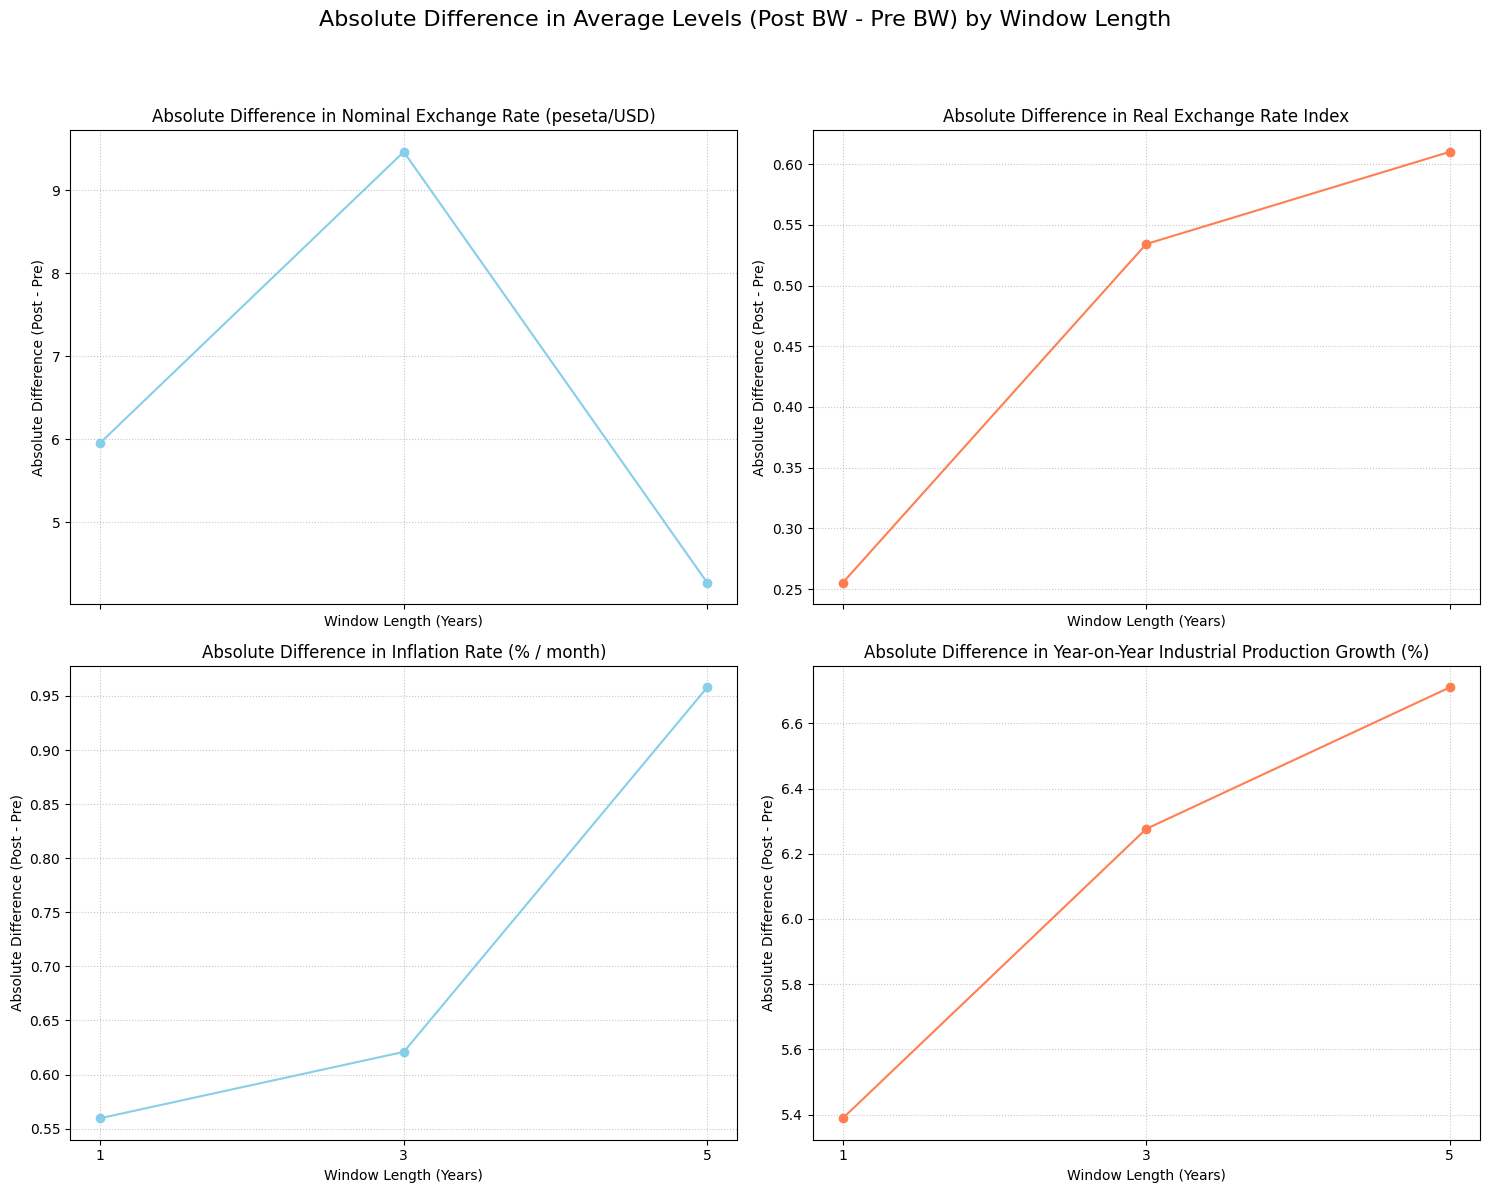

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df_results and analysis_variables are available from the previous step

# Create a DataFrame to store the differences
differences_df = pd.DataFrame(columns=['Variable', 'Window (Years)', 'Difference (Post - Pre)'])

for var_col, var_name in analysis_variables.items():
    # Filter for the current variable
    var_data = df_results[df_results['Variable'] == var_name]

    for window_years in window_lengths:
        pre_avg = var_data[(var_data['Window (Years)'] == window_years) & (var_data['Period'] == 'Pre-Bretton Woods (Avg)')]['Value'].iloc[0]
        post_avg = var_data[(var_data['Window (Years)'] == window_years) & (var_data['Period'] == 'Post-Bretton Woods (Avg)')]['Value'].iloc[0]
        diff = abs(post_avg - pre_avg)
        differences_df = pd.concat([differences_df, pd.DataFrame([{'Variable': var_name, 'Window (Years)': window_years, 'Difference (Post - Pre)': diff}])], ignore_index=True)

# Create a figure and a set of subplots in a 2x2 matrix
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True)
fig.suptitle('Absolute Difference in Average Levels (Post BW - Pre BW) by Window Length', fontsize=16, y=1.02)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Define colors for alternating lines
colors = ['skyblue', 'coral']

# Plot each variable's differences
for i, (var_col, var_name) in enumerate(analysis_variables.items()):
    ax = axes[i]
    plot_data = differences_df[differences_df['Variable'] == var_name]
    color = colors[i % len(colors)] # Alternating colors
    ax.plot(plot_data['Window (Years)'], plot_data['Difference (Post - Pre)'], marker='o', linestyle='-', color=color)
    ax.set_title(f'Absolute Difference in {var_name}')
    ax.set_xlabel('Window Length (Years)')
    ax.set_ylabel('Absolute Difference (Post - Pre)')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.set_xticks(window_lengths) # Ensure all window lengths are shown as ticks
    # Removed ax.axhline(0, color='gray', linestyle='--', linewidth=0.8) as it's not relevant for absolute differences

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()


### 5.1.4, Answers to the Questions
**Q1: Is there evidence that average levels changed markedly around the end of Bretton Woods? Nominal and Real Exchange Rates?**

- Yes, the nominal exchange rate changed notably.

The average level of pesetas per USD rose from 63.17 pre-Bretton Woods to 100.83 post-Bretton Woods — a 60% increase (ratio of 1.60), reflecting the peseta's depreciation once it was free to float The real exchange rate index fell from an average of 2.23 to 1.47 (ratio of 0.66), meaning the peseta appreciated in real terms post-1973, likely driven by Spain's higher inflation eating into the nominal depreciation.

- Inflation:

Average monthly inflation more than doubled from 0.48% pre-Bretton Woods to 1.00% post-Bretton Woods (ratio of 2.10), suggesting inflation became significantly more serious after the fixed exchange rate was removed.

- Industrial Production Growth:

The most dramatic change — average 12-monthly industrial production growth collapsed from 10.54% pre-Bretton Woods to just 2.58% post-Bretton Woods (ratio of 0.25).


**Q2: How do results change with longer periods?**

Looking at the windowed comparison table (±1, ±3, ±5 years around 1973):

The nominal exchange rate pre-average rises from 63.67 (±1 year) to 68.49 (±5 years), while the post-average rises from 57.64 to 63.86, meaning the gap between pre and post actually narrows with longer windows (despite the abrupt rise for the 3-year window length: perhaps exogenous events impacted Spain significantly).

Inflation's post-average increases from 1.23 (±1 year) to 1.46 (±5 years), suggesting inflation kept rising for several years after 1973, so longer windows capture more of this increase.

Industrial production growth post-average falls from 10.66 (±1 year) to 4.37 (±5 years), meaning the growth slow-down looks worse over longer windows as Spain's post-oil-crisis recession is captured.

Overall, results become more sensitive to events far from 1973 as windows widen, making the before/after comparison less 'clean'.


**Q3: What issues are there with using longer periods to infer causality?**

Confounding events — the 1973 and 1979 oil shocks, Spain's political transition to democracy after Franco's death in 1975, and global recessions, all occurred in the post-1973 period. Longer windows capture these events, making it impossible to isolate the effect of the exchange rate regime change alone.

Meanwhile, the Spanish Miracle — Spain's unusually high industrial production growth pre-1973 (averaging 10.5%) -- reflected a very unique phase of growth, not just the impacts from the fixed exchange rate. Attributing the post-1973 slowdown to exchange rate flexibility is therefore misleading. Confounders over long periods, such as structural changes in the Spanish economy (industrialisation, EU accession process, labour market changes), thus similarly affect all variables independently of exchange rate.

Last but not least, these could still be risks of Reverse Causality: Spain's higher post-1973 inflation may have caused the peseta to depreciate, rather than exchange rate volatility causing inflation.

## 5.2, Black Wednesday: The UK Joining & Leaving the ERM

### 5.2.1, Loading Data/creating variables
Reading .csv files from my github.

In [ ]:
# Load raw dataframes
Deu_CPI = pd.read_csv(
    'https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/Deutschland_CPI.csv'
    ).rename(columns={"OBS_VALUE": 'CPI'}).drop(columns=['INDEX_TYPE'])
Deu_nER = pd.read_csv(
    'https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/Deutschland_ER_per$_monthly_averages.csv'
    ).rename(columns={'OBS_VALUE': 'nER/$'}).drop(columns=['INDICATOR'])
UK_CPI = pd.read_csv(
    'https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/UK_CPI.csv'
    ).rename(columns={'OBS_VALUE': 'CPI'}).drop(columns=['INDEX_TYPE'])
UK_nER = pd.read_csv(
    'https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/UK_ER_per$_monthly_averages.csv'
    ).rename(columns={'OBS_VALUE': 'nER/$'}).drop(columns=['INDICATOR'])
UK_ind_prod = pd.read_csv(
    'https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/UK_industrial_production.csv'
    ).rename(columns={'OBS_VALUE': 'ind_prod'}).drop(columns=['PRODUCTION_INDEX'])
UK_res = pd.read_csv(
    'https://raw.githubusercontent.com/Chevalier23333/EC1B1-Python-Coursework/main/UK_total_reserves_$mn_monthly.csv'
    ).rename(columns={'OBS_VALUE': 'res'}).drop(columns=['INDICATOR', 'UNIT', 'SCALE'])

# Merge and rename columns to create 'germany' and 'uk' (previously in cell F6IhUmDND5MK)
germany = pd.merge(Deu_CPI, Deu_nER, on=['COUNTRY', 'TIME_PERIOD']).rename(columns={'COUNTRY': 'country', "TIME_PERIOD": 'time'})
uk = UK_CPI.merge(UK_nER, on=['COUNTRY', 'TIME_PERIOD']).merge(UK_ind_prod, on=['COUNTRY', 'TIME_PERIOD']).merge(UK_res, on=['COUNTRY', 'TIME_PERIOD']).rename(columns={'COUNTRY': 'country', "TIME_PERIOD": 'time'})

# Convert the 'time' column to Period type for both DataFrames (in-place modification)
germany['time'] = pd.to_datetime(germany['time'], format='%Y-M%m').dt.to_period('M')
uk['time'] = pd.to_datetime(uk['time'], format='%Y-M%m').dt.to_period('M')

# Create a temporary merged dataframe for cross-country calculations
# This dataframe will contain time, CPI and nER for both UK and Germany
temp_merged_df = pd.merge(
    uk[['time', 'nER/$', 'CPI', 'res', 'ind_prod']], # Include necessary columns from UK for later assignment
    germany[['time', 'nER/$', 'CPI']],
    on='time',
    suffixes=('_uk', '_de'),
    how='inner' # Use inner merge to ensure common time periods
)

# Ensure columns are numeric for calculations
for col in ['nER/$_uk', 'CPI_uk', 'res', 'ind_prod', 'nER/$_de', 'CPI_de']:
    if col in temp_merged_df.columns:
        temp_merged_df[col] = pd.to_numeric(temp_merged_df[col], errors='coerce')

# 1. ER_UK_Nom_Growth: Monthly percentage change in the UK/USD nominal exchange rate.
uk['ER_UK_Nom_Growth'] = uk['nER/$'].pct_change() * 100

# 2. DM_GBP_Nominal_ER: The DM/£ exchange rate, calculated as (DEM per USD) / (GBP per USD).
temp_merged_df['DM_GBP_Nominal_ER'] = temp_merged_df['nER/$_de'] / temp_merged_df['nER/$_uk']
uk = pd.merge(uk, temp_merged_df[['time', 'DM_GBP_Nominal_ER']], on='time', how='left') # Merge back to uk

# 3. DM_GBP_Nominal_Growth: Monthly percentage change in the DM/£ nominal exchange rate.
uk['DM_GBP_Nominal_Growth'] = uk['DM_GBP_Nominal_ER'].pct_change() * 100

# 4. DM_GBP_Real_ER: RealDM/£ER=(DM/£)×(CPIUK/CPIGermany)
temp_merged_df['DM_GBP_Real_ER'] = temp_merged_df['DM_GBP_Nominal_ER'] * (temp_merged_df['CPI_uk'] / temp_merged_df['CPI_de'])
uk = pd.merge(uk, temp_merged_df[['time', 'DM_GBP_Real_ER']], on='time', how='left') # Merge back to uk

# 5. DM_GBP_Real_Growth: Monthly percentage change in the real DM/£ exchange rate.
uk['DM_GBP_Real_Growth'] = uk['DM_GBP_Real_ER'].pct_change() * 100

# 6. Inflation_UK: Monthly percentage change in the UK CPI.
uk['Inflation_UK'] = uk['CPI'].pct_change() * 100

# 7. Inflation_Germany: Monthly percentage change in the German CPI.
germany['Inflation_Germany'] = germany['CPI'].pct_change() * 100

# 8. PI_UK_Growth_Monthly: Monthly percentage change in UK Industrial Production.
uk['PI_UK_Growth_Monthly'] = uk['ind_prod'].pct_change() * 100

# 9. PI_UK_Growth_YoY: Percentage change in UK Industrial Production compared to the same month in the previous year.
uk['PI_UK_Growth_YoY'] = uk['ind_prod'].pct_change(periods=12) * 100

# 10. IL_UK_Index_1985: UK international reserves index (January 1985 = 100).
# Find the value of UK reserves in January 1985
res_jan_1985_series = uk[uk['time'] == pd.Period('1985-01', 'M')]['res']
if not res_jan_1985_series.empty:
    res_jan_1985 = res_jan_1985_series.iloc[0]
    uk['IL_UK_Index_1985'] = 100 * uk['res'] / res_jan_1985
else:
    print("Warning: January 1985 reserves not found for UK. IL_UK_Index_1985 not calculated.")
    uk['IL_UK_Index_1985'] = pd.NA # Or fill with NaN

print("UK DataFrame with new variables:")
display(uk.head())
print("\nGermany DataFrame with new variables:")
display(germany.head())

UK DataFrame with new variables:


,country,time,CPI,nER/$,ind_prod,res,ER_UK_Nom_Growth,DM_GBP_Nominal_ER,DM_GBP_Nominal_Growth,DM_GBP_Real_ER,DM_GBP_Real_Growth,Inflation_UK,PI_UK_Growth_Monthly,PI_UK_Growth_YoY,IL_UK_Index_1985
0,United Kingdom,1985-01,41.40639,0.885801,68.252953,14686.404136,NaN,3.576085,NaN,2.673683,NaN,NaN,NaN,NaN,100.000000
1,United Kingdom,1985-02,41.72420,0.912660,74.929872,14298.070901,3.032171,3.607148,0.868630,2.705516,1.190579,0.767539,9.782609,NaN,97.355832
2,United Kingdom,1985-03,42.13282,0.894962,78.639272,13788.951232,-1.939167,3.697587,2.507211,2.791195,3.166841,0.979336,4.950495,NaN,93.889226
3,United Kingdom,1985-04,43.04085,0.805316,69.458508,14278.858630,-10.016738,3.828311,3.535379,2.948887,5.649602,2.155161,-11.674528,NaN,97.225015
4,United Kingdom,1985-05,43.22246,0.800777,69.087568,14260.156688,-0.563630,3.888598,1.574776,3.007964,2.003369,0.421948,-0.534045,NaN,97.097673



Germany DataFrame with new variables:


,country,time,CPI,nER/$,Inflation_Germany
0,Germany,1985-01,55.38157,3.1677,NaN
1,Germany,1985-02,55.62909,3.2921,0.446936
2,Germany,1985-03,55.81472,3.3092,0.333692
3,Germany,1985-04,55.87660,3.0830,0.110867
4,Germany,1985-05,55.87660,3.1139,0.000000


### 5.2.2, Key UK Economic Indicators (1985-1997)

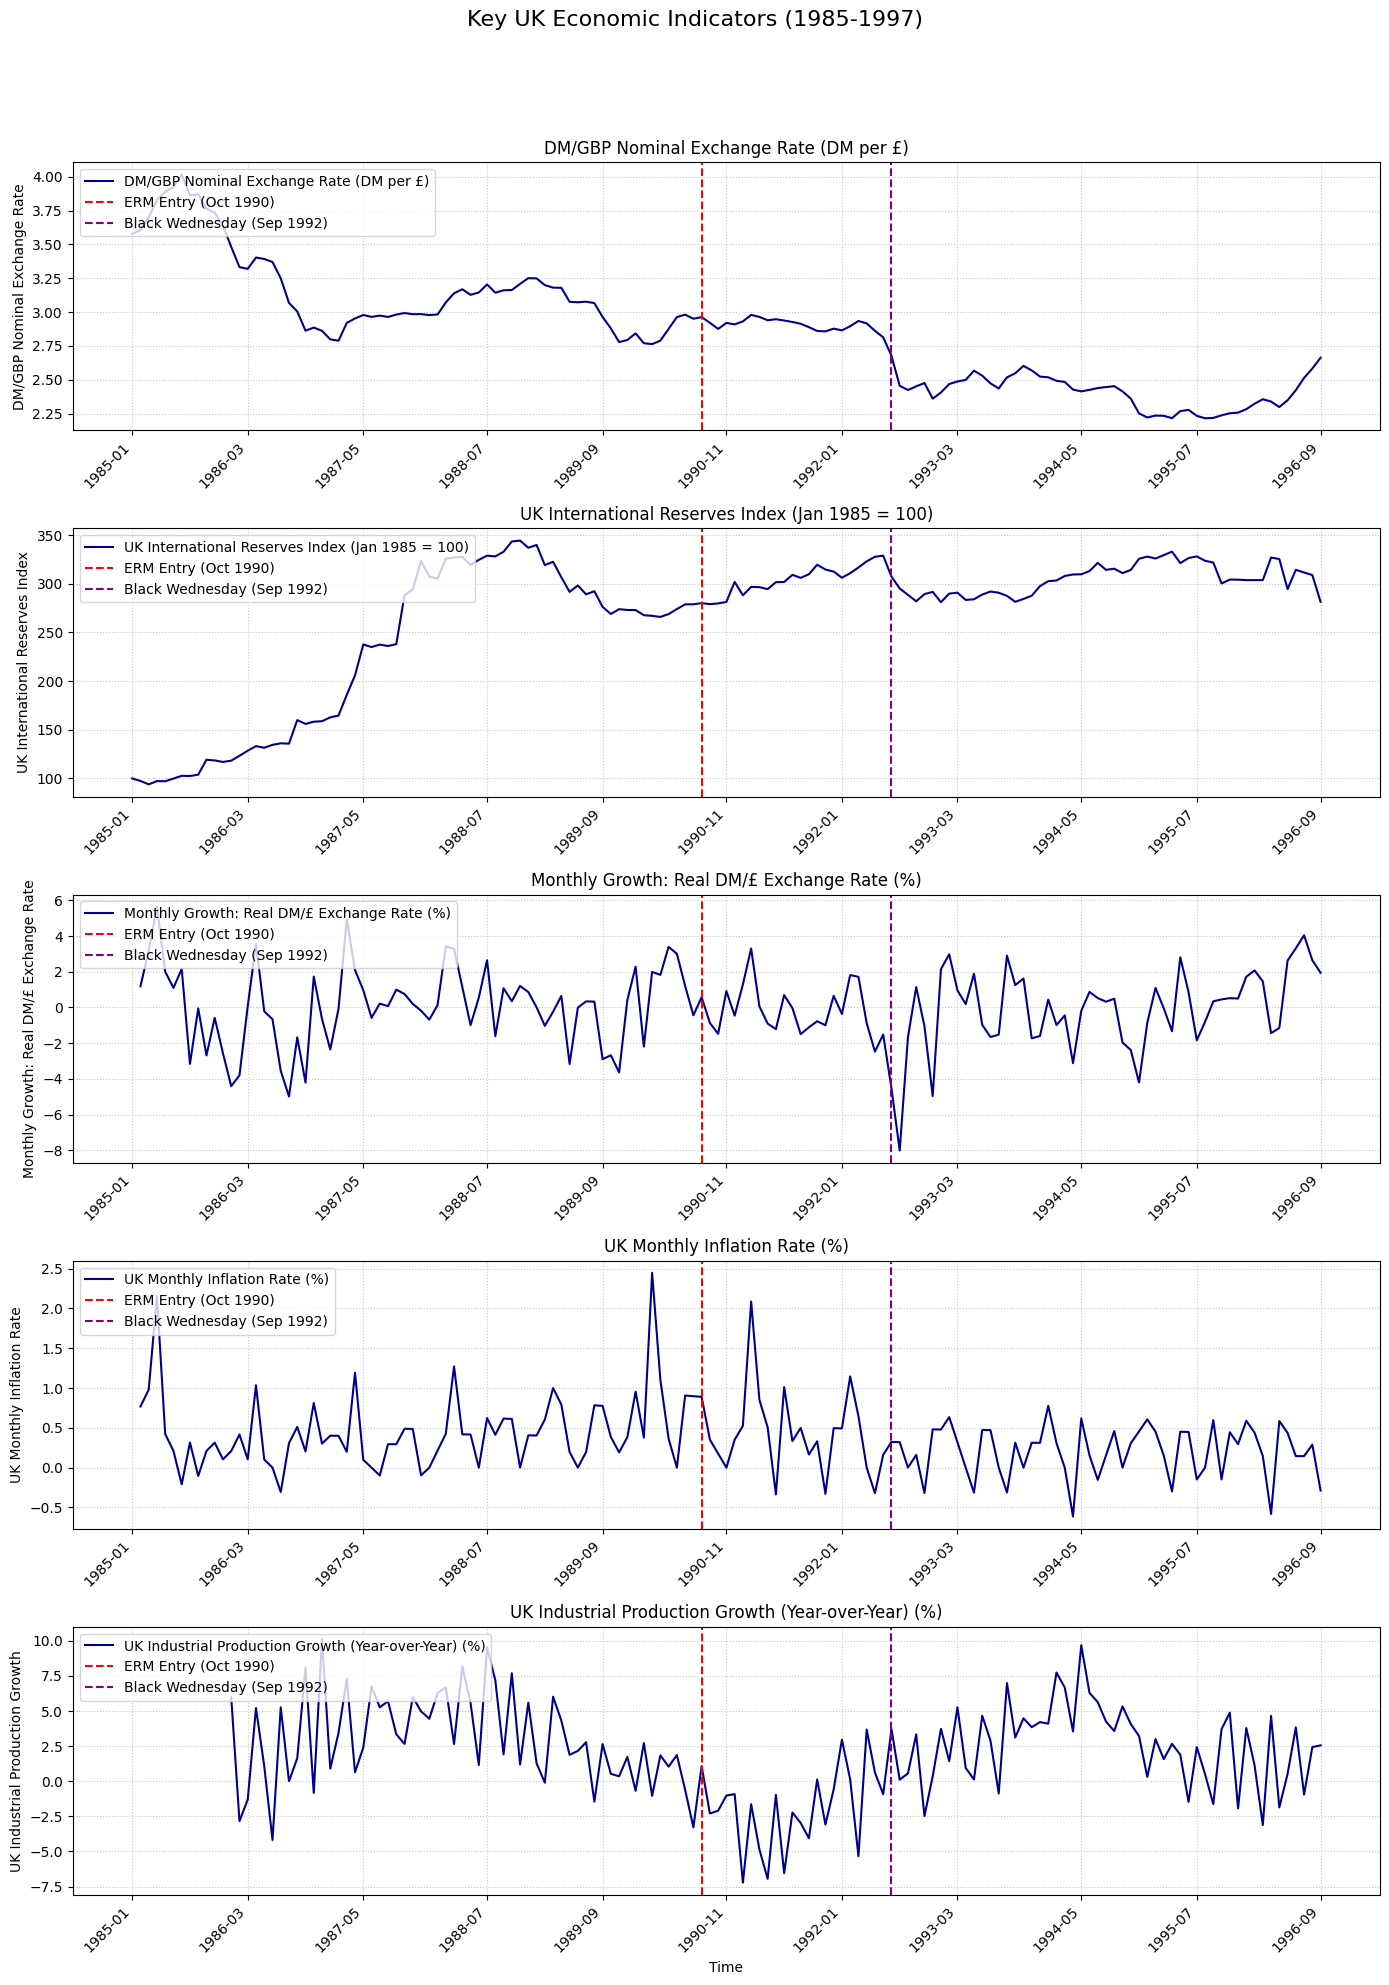

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the period for filtering
start_period_bw = pd.Period('1985-01', 'M')
end_period_bw = pd.Period('1997-12', 'M')

# Filter the UK DataFrame for the specified period
filtered_uk_extended = uk[(uk['time'] >= start_period_bw) & (uk['time'] <= end_period_bw)].copy()

# Ensure relevant columns are numeric
for col in ['DM_GBP_Nominal_ER', 'IL_UK_Index_1985', 'DM_GBP_Real_Growth', 'Inflation_UK', 'PI_UK_Growth_YoY']:
    filtered_uk_extended[col] = pd.to_numeric(filtered_uk_extended[col], errors='coerce')

# Define the variables to plot and their titles
plot_vars_extended = {
    'DM_GBP_Nominal_ER': 'DM/GBP Nominal Exchange Rate (DM per £)',
    'IL_UK_Index_1985': 'UK International Reserves Index (Jan 1985 = 100)',
    'DM_GBP_Real_Growth': 'Monthly Growth: Real DM/£ Exchange Rate (%)',
    'Inflation_UK': 'UK Monthly Inflation Rate (%)',
    'PI_UK_Growth_YoY': 'UK Industrial Production Growth (Year-over-Year) (%)'
}

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=len(plot_vars_extended), ncols=1, figsize=(14, 20), sharex=True)
fig.suptitle('Key UK Economic Indicators (1985-1997)', fontsize=16, y=1.02)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Add vertical lines for key events
erm_entry_period = pd.Period('1990-10', 'M')
bw_period = pd.Period('1992-09', 'M')

for i, (col, title) in enumerate(plot_vars_extended.items()):
    ax = axes[i]
    ax.plot(filtered_uk_extended['time'].astype(str), filtered_uk_extended[col], label=title, color='darkblue')
    ax.set_ylabel(title.split('(')[0].strip()) # Use part of title as y-label
    ax.set_title(title, fontsize=12)
    ax.axvline(x=erm_entry_period.strftime('%Y-%m'), color='red', linestyle='--', linewidth=1.5, label='ERM Entry (Oct 1990)')
    ax.axvline(x=bw_period.strftime('%Y-%m'), color='purple', linestyle='--', linewidth=1.5, label='Black Wednesday (Sep 1992)')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper left')
    if i == len(plot_vars_extended) - 1: # Only add x-label to the last subplot
        ax.set_xlabel('Time')

# Improve x-axis tick readability for PeriodIndex
n_ticks = 10 # Number of ticks to display
tick_labels_extended = filtered_uk_extended['time'].iloc[::len(filtered_uk_extended['time']) // n_ticks].astype(str)
tick_positions_extended = np.linspace(0, len(filtered_uk_extended) - 1, len(tick_labels_extended), dtype=int)

for ax in axes:
    ax.set_xticks(tick_positions_extended)
    ax.set_xticklabels(tick_labels_extended, rotation=45, ha='right')
    ax.tick_params(labelbottom=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

### 5.2.3, Standard Deviation Analysis: Pre-ERM, ERM, and Post-ERM Periods

In [ ]:
# Define the periods for Pre-ERM, ERM, and Post-ERM
# ERM Entry: October 1990
# Black Wednesday (ERM Exit): September 1992

period_pre_erm_start = pd.Period('1985-01', 'M') # Start of available data
period_pre_erm_end = pd.Period('1990-09', 'M') # One month before ERM entry

period_erm_start = pd.Period('1990-10', 'M') # ERM entry
period_erm_end = pd.Period('1992-08', 'M') # One month before ERM exit

period_post_erm_start = pd.Period('1992-09', 'M') # ERM exit (Black Wednesday)
period_post_erm_end = pd.Period('1997-12', 'M') # End of available data

# Filter UK data for each period
uk_pre_erm = uk[(uk['time'] >= period_pre_erm_start) & (uk['time'] <= period_pre_erm_end)].copy()
uk_erm = uk[(uk['time'] >= period_erm_start) & (uk['time'] <= period_erm_end)].copy()
uk_post_erm = uk[(uk['time'] >= period_post_erm_start) & (uk['time'] <= period_post_erm_end)].copy()

# Define variables to calculate standard deviation for
# Using the variables previously generated and plotted where appropriate for volatility
variables = {
    'DM_GBP_Nominal_Growth': 'DM/GBP Nominal Exchange Rate Growth',
    'DM_GBP_Real_Growth': 'DM/GBP Real Exchange Rate Growth',
    'Inflation_UK': 'UK Monthly Inflation Rate',
    'PI_UK_Growth_YoY': 'UK Industrial Production Growth (YoY)',
    'ER_UK_Nom_Growth': 'UK/USD Nominal Exchange Rate Growth'
}

# Ensure all relevant columns are numeric before calculating standard deviation
for df_temp in [uk_pre_erm, uk_erm, uk_post_erm]:
    for col in variables.keys():
        if col in df_temp.columns:
            df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

# Prepare a list to store results
results_erm = []

for var_key, var_name in variables.items():
    std_pre_erm = uk_pre_erm[var_key].std()
    std_erm = uk_erm[var_key].std()
    std_post_erm = uk_post_erm[var_key].std()

    # Calculate ratios for comparison
    ratio_erm_pre = std_erm / std_pre_erm if std_pre_erm != 0 else np.nan
    ratio_post_erm_erm = std_post_erm / std_erm if std_erm != 0 else np.nan

    results_erm.append({
        'Variable': var_name,
        'Std Dev Pre-ERM (Jan 1985 - Sep 1990)': std_pre_erm,
        'Std Dev ERM (Oct 1990 - Aug 1992)': std_erm,
        'Std Dev Post-ERM (Sep 1992 - Dec 1997)': std_post_erm,
        'Ratio (ERM/Pre-ERM)': ratio_erm_pre,
        'Ratio (Post-ERM/ERM)': ratio_post_erm_erm
    })

# Create a DataFrame from the results
results_erm_df = pd.DataFrame(results_erm)

# Display the formatted table
print("Standard Deviations Before, During, and After ERM for the UK:")
display(results_erm_df.round(4))

Standard Deviations Before, During, and After ERM for the UK:


,Variable,Std Dev Pre-ERM (Jan 1985 - Sep 1990),Std Dev ERM (Oct 1990 - Aug 1992),Std Dev Post-ERM (Sep 1992 - Dec 1997),Ratio (ERM/Pre-ERM),Ratio (Post-ERM/ERM)
0,DM/GBP Nominal Exchange Rate Growth,2.1291,1.0216,2.2981,0.4798,2.2494
1,DM/GBP Real Exchange Rate Growth,2.2593,1.3521,2.2841,0.5985,1.6892
2,UK Monthly Inflation Rate,0.4786,0.5392,0.3241,1.1266,0.6011
3,UK Industrial Production Growth (YoY),3.2838,2.9143,2.7376,0.8875,0.9394
4,UK/USD Nominal Exchange Rate Growth,2.9866,2.9308,2.7411,0.9813,0.9353


### 5.2.4, Average Levels Analysis: Pre-ERM, ERM, and Post-ERM Periods

In [ ]:
# Define the periods for Pre-ERM, ERM, and Post-ERM
# ERM Entry: October 1990
# Black Wednesday (ERM Exit): September 1992

period_pre_erm_start = pd.Period('1985-01', 'M') # Start of available data
period_pre_erm_end = pd.Period('1990-09', 'M') # One month before ERM entry

period_erm_start = pd.Period('1990-10', 'M') # ERM entry
period_erm_end = pd.Period('1992-08', 'M') # One month before ERM exit

period_post_erm_start = pd.Period('1992-09', 'M') # ERM exit (Black Wednesday)
period_post_erm_end = pd.Period('1997-12', 'M') # End of available data

# Filter UK data for each period
uk_pre_erm_avg = uk[(uk['time'] >= period_pre_erm_start) & (uk['time'] <= period_pre_erm_end)].copy()
uk_erm_avg = uk[(uk['time'] >= period_erm_start) & (uk['time'] <= period_erm_end)].copy()
uk_post_erm_avg = uk[(uk['time'] >= period_post_erm_start) & (uk['time'] <= period_post_erm_end)].copy()

# Define variables to calculate mean for
variables_for_mean = {
    'DM_GBP_Nominal_ER': 'DM/GBP Nominal Exchange Rate',
    'IL_UK_Index_1985': 'UK International Reserves Index',
    'Inflation_UK': 'UK Monthly Inflation Rate',
    'PI_UK_Growth_YoY': 'UK Industrial Production Growth (YoY)'
}

# Ensure all relevant columns are numeric before calculating means
for df_temp in [uk_pre_erm_avg, uk_erm_avg, uk_post_erm_avg]:
    for col in variables_for_mean.keys():
        if col in df_temp.columns:
            df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

# Prepare a list to store results
results_erm_mean = []

for var_key, var_name in variables_for_mean.items():
    mean_pre_erm = uk_pre_erm_avg[var_key].mean()
    mean_erm = uk_erm_avg[var_key].mean()
    mean_post_erm = uk_post_erm_avg[var_key].mean()

    # Calculate ratios for comparison
    # Use np.nan for division by zero to avoid errors
    ratio_erm_pre = mean_erm / mean_pre_erm if mean_pre_erm != 0 else np.nan
    ratio_post_erm_erm = mean_post_erm / mean_erm if mean_erm != 0 else np.nan

    # Calculate differences for interpretation
    diff_erm_pre = mean_erm - mean_pre_erm
    diff_post_erm_erm = mean_post_erm - mean_erm

    results_erm_mean.append({
        'Variable': var_name,
        'Mean Pre-ERM (Jan 1985 - Sep 1990)': mean_pre_erm,
        'Mean ERM (Oct 1990 - Aug 1992)': mean_erm,
        'Mean Post-ERM (Sep 1992 - Dec 1997)': mean_post_erm,
        'Ratio (ERM/Pre-ERM)': ratio_erm_pre,
        'Ratio (Post-ERM/ERM)': ratio_post_erm_erm,
        'Diff (ERM - Pre-ERM)': diff_erm_pre,
        'Diff (Post-ERM - ERM)': diff_post_erm_erm
    })

# Create a DataFrame from the results
results_erm_mean_df = pd.DataFrame(results_erm_mean)

# Display the formatted table
print("Average Levels Before, During, and After ERM for the UK:")
display(results_erm_mean_df.round(4))


Average Levels Before, During, and After ERM for the UK:


,Variable,Mean Pre-ERM (Jan 1985 - Sep 1990),Mean ERM (Oct 1990 - Aug 1992),Mean Post-ERM (Sep 1992 - Dec 1997),Ratio (ERM/Pre-ERM),Ratio (Post-ERM/ERM),Diff (ERM - Pre-ERM),Diff (Post-ERM - ERM)
0,DM/GBP Nominal Exchange Rate,3.1752,2.9082,2.4069,0.9159,0.8276,-0.2670,-0.5013
1,UK International Reserves Index,227.6718,303.7637,304.9446,1.3342,1.0039,76.0919,1.1809
2,UK Monthly Inflation Rate,0.4514,0.4364,0.2050,0.9668,0.4697,-0.0150,-0.2314
3,UK Industrial Production Growth (YoY),2.9748,-1.9637,2.6296,-0.6601,-1.3391,-4.9385,4.5933


**Visualization of Average Levels (Pre-ERM, ERM, and Post-ERM Periods)**

This bar chart visualizes the average levels calculated in the previous step, providing a clear comparison of economic conditions before, during, and after the UK's membership in the ERM.

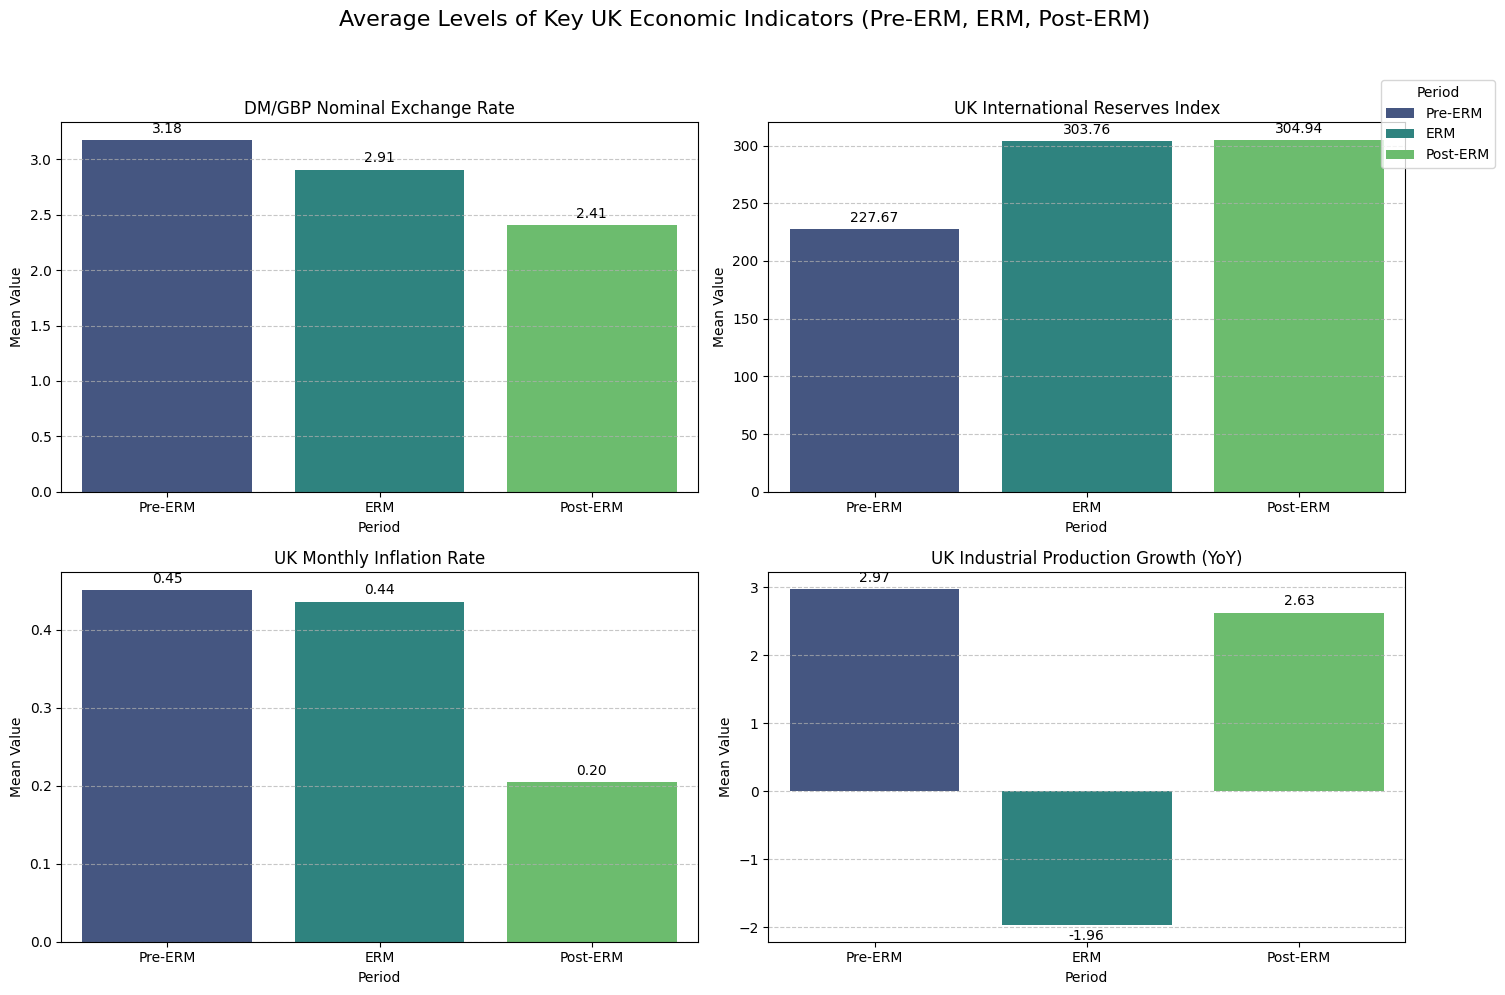

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_erm_mean_df = results_erm_mean_df.melt(id_vars='Variable',
                                            value_vars=['Mean Pre-ERM (Jan 1985 - Sep 1990)', 'Mean ERM (Oct 1990 - Aug 1992)', 'Mean Post-ERM (Sep 1992 - Dec 1997)'],
                                            var_name='Period', value_name='Mean Value')

# Rename periods for better plot labels
plot_erm_mean_df['Period'] = plot_erm_mean_df['Period'].replace({
    'Mean Pre-ERM (Jan 1985 - Sep 1990)': 'Pre-ERM',
    'Mean ERM (Oct 1990 - Aug 1992)': 'ERM',
    'Mean Post-ERM (Sep 1992 - Dec 1997)': 'Post-ERM'
})

# Create a figure and a set of subplots for each variable
# Changed nrows from len(variables_for_mean) to 2, and ncols from 1 to 2 for a 2x2 grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False) # Adjusted figsize for 2x2
fig.suptitle('Average Levels of Key UK Economic Indicators (Pre-ERM, ERM, Post-ERM)', fontsize=16, y=1.02)

# Flatten axes for easy iteration
axes = axes.flatten()

# To manage a single legend for the figure, we plot the first one with a legend, then remove it
# and then add a figure legend later.
legend_handles = []
legend_labels = []

for i, var_name in enumerate(variables_for_mean.values()):
    ax = axes[i]
    # Set legend=True only for the first subplot to capture handles/labels, then False for others
    sns.barplot(x='Period', y='Mean Value', data=plot_erm_mean_df[plot_erm_mean_df['Variable'] == var_name],
                palette='viridis', ax=ax, hue='Period', legend=(i == 0)) # Legend only for first plot
    ax.set_title(var_name, fontsize=12)
    ax.set_xlabel('Period') # Explicit x-label for each subplot for clarity in a grid
    ax.set_ylabel('Mean Value')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10, padding=3)

    if i == 0: # Capture legend handles/labels from the first plot
        h, l = ax.get_legend_handles_labels()
        legend_handles.extend(h)
        legend_labels.extend(l)
    if ax.get_legend() is not None:
        ax.get_legend().remove() # Remove individual legend if created

# Add a single legend to the figure outside the subplots
fig.legend(legend_handles, legend_labels, title='Period', loc='upper right', bbox_to_anchor=(1.0, 0.95), borderaxespad=0.)

plt.tight_layout(rect=[0, 0.03, 0.95, 0.98]) # Adjust tight_layout to make space for the figure legend
plt.show()


### 5.2.5, Answers to the Questions
**Q1: What was a key reason for why the UK chose to join the ERM?**

It is perceived that Inflation was a key driver for the UK to join the ERM: UK's inflation was hitting high during 1990 with a maximal rate of 2.5% PER MONTH. Given that the Deutsche Mark was a stable standard currency held by Germany's Bundesbank to counter inflationary risks in the newly reunified Germany, pegging the GBP to the Deutsche Mark could stabilise the UK's domestic inflation through a series of operations. While inflation stayed high and the GBP was held to not depreciate naturally, the market would see that the GBP was overvalued and attempt to sell GBP in exchange for currencies that did better in value storing, causing depreciatory pressure on GBP. To maintain a stable exchange rate, the Bank of England must buy in GBP to exert appreciatory pressure. This would reduce money supply in Britain and counter domestic inflation. However, after joining the ERM, the average level of inflation rate seemed to decrease only marginally (from 0.45% monthly average before to 0.44% monthly average during the ERM era).

**Q2: What factors led to Soros and speculators to run on the pound?**

We suggest two reasons:

1.	Trend in Sterling's exchange rate and valuation provided the chance.
Across the 1985-1996 period, it was observable that the pound was roughly following a dropping trend, and during the last few months in the ERM this trend was exceptionally potent, reflecting the market's recognition that the pound was overvalued under the managed exchange rate system. Besides, even after joining the ERM, inflation in the UK still recorded some extraordinary values, exceeding 2.0% per month around early 1991 and exceeding 1.0% per month during the last few months in the ERM. These could have enhanced the market's suspicion in the pound's value-storing ability and confirmed the recognition that the pound was overvalued. Utilizing such mindsets, Soros could excessively sell out the pound and smash on the pound's exchange rate to increase the suspicion on Sterling's value, causing the market to doubt the pound's value and sell out the pound collectively.

2.	Keeping a managed exchange rate was essentially Unnatural for the scenario the UK was faced with.
Industrial production in the UK seemed terrible during the ERM years (average year-on-year growth was negative 1.96), and it would be natural to allow the pound to drop while lowering interest rates to stimulate domestic production by enhancing British exports' price competitiveness and encouraging borrowing. However, with a managed exchange rate, the Bank of England had to buy in the pound to counter depreciatory pressure, reducing money supply; meanwhile, it could not freely lower interest rates because of concerns of hot money outflows (to countries where rates were higher for saving, e.g., the newly reunited Deutschland), which would include selling pounds to cause more depreciatory pressure. It thus seemed not a sustainable choice to persistently maintain the pegged exchange rate in sacrifice of limited foreign reserves and domestic economy.


**Q3: Is there evidence of changes in volatility after joining/leaving the ERM?**

Looking at the Standard Deviation Table (5.2.3):

1.	For DM/GBP exchange rate growth itself, there was evidence of changes in volatility after joining and leaving the ERM.
It was observable that joining the managed exchange rate system reduced the dispersion in the growth rates of nominal and real DM/GBP exchange rates: the ERM/pre-ERM ratios for the standard deviations of the two growth rates were respectively 0.4798 and 0.5985. Leaving the ERM made the growth rates of nominal and real DM/GBP figures bounce volatile again: the post-ERM/ERM ratios for the two growth rates were 2.249 and 1.689.

2.	Joining the ERM didn't seem to cause significant impacts on the volatility of key economic performances such as inflation and industrial production. The standard deviations of inflation rates and year-on-year industrial production growth compared similar to their pre-ERM levels during the ERM period (ERM/pre-ERM ratios for the standard deviations were 1.1266 and 0.8875, both close to 1). While leaving the ERM did not seem to impact industrial production much (post-ERM/ERM standard deviation ratio was 0.9394, still close to 1), it seemed conversely that leaving the ERM stabilized inflation: the post-ERM/ERM standard deviation ratio for UK's monthly inflation was 0.6011, almost halving the volatility of inflation.

3.	Nor did external exchange rates, like the UK/USD rate, seem impacted because of joining or leaving the ERM. Both the ERM/pre-ERM and the post-ERM/ERM standard deviation ratios of the growth of UK/USD nominal exchange rate were both very close to 1.

**Q4: Changes in levels following Black Wednesday?**

From the line graphs:
Nominal DM/GBP exchange rate was allowed to fall sharply, so did the real DM/GBP exchange rate, confirming an essential decline in the pound's value or purchasing power.

Combining the Average Level Bar Plots and the Standard Deviation Table:
Inflation was stabilized on a much lower average level (0.20% per month) compared to the ERM era (0.44% per month), also considering a much lower level of volatility (as in the answer to Q3).
Industrial Production rebounded. Post-ERM average levelled at 2.63 index value as a definite reverse to the -1.96 index value during the ERM era, while it has been analyzed that volatility did not significantly change.

**Q5: What concerns do you have about drawing conclusions from this period?**

1.	The ERM era was too short: only 2 years of data (Oct 1990 to Sep 1992) makes it very difficult to draw solid conclusions. Standard deviations and averages based on just 24 months are highly sensitive to individual outliers: the period could be coincidently a particularly weak time for the British economy, and the economy was facing the dilemma of keeping exchange rate stable against restoring domestic economic performances. All these specific cases could have made this historical era 'special' and ungeneralisable for analyses regarding the importance of exchange rates though we seem to conclude that exchange rates are not in fact so important as they used to be reckoned. It might be that in other cases (like Spain's cases), there would be some remarkable changes that are potentially associated with exchange rate volatility.

2.	Confounding factors: the ERM period coincided with a global recession and the Gulf War (1990-91), which independently depressed UK industrial production. It is hard to separate the effect of the exchange rate peg from these external shocks. German reunification also caused abnormally high German interest rates, which forced the conflict between UK's domestic economic restoration and exchange rate requirements. This was a very unique event that seems unlikely to repeat.

3.	Policy would have changed after the Black Wednesday: the UK adopted official inflation targeting to reduced inflation volatility on its own. This makes it hard to attribute the post-ERM inflation improvement solely to exchange rate flexibility.